In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pathlib import Path
import xgboost as xgb
from catboost import CatBoostClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
pd.set_option('display.max_columns', None)

In [2]:
PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

CSV_PATH = (
    PROJECT_ROOT
    / "data"
    / "WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

if not CSV_PATH.exists():
    raise FileNotFoundError(
        f"CSV file was not found at:\n{CSV_PATH}\n\n"
        "Copy the dataset into the project's data folder."
    )

print(f"Dataset path: {CSV_PATH}")
print(f"File size: {CSV_PATH.stat().st_size / 1024:.1f} KB")

Dataset path: D:\work\telco-churn-assistant\data\WA_Fn-UseC_-Telco-Customer-Churn.csv
File size: 954.6 KB


In [3]:
raw_df = pd.read_csv(CSV_PATH)

#copy the data
df = raw_df.copy()

print("Dataset loaded successfully.")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Dataset loaded successfully.
Rows: 7,043
Columns: 21


Data Inspection

In [4]:
display(df.head())

,customerID,gender,Senior_Citizen,Is_Married,Dependents,tenure,Phone_Service,Dual,Internet_Service,Online_Security,Online_Backup,Device_Protection,Tech_Support,Streaming_TV,Streaming_Movies,Contract,Paperless_Billing,Payment_Method,Monthly_Charges,Total_Charges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
display(df.sample(5, random_state=42))

,customerID,gender,Senior_Citizen,Is_Married,Dependents,tenure,Phone_Service,Dual,Internet_Service,Online_Security,Online_Backup,Device_Protection,Tech_Support,Streaming_TV,Streaming_Movies,Contract,Paperless_Billing,Payment_Method,Monthly_Charges,Total_Charges,Churn
185,1024-GUALD,Female,0,Yes,No,1,No,No phone service,DSL,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,24.80,24.8,Yes
2715,0484-JPBRU,Male,0,No,No,41,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Bank transfer (automatic),25.25,996.45,No
3825,3620-EHIMZ,Female,0,Yes,Yes,52,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.35,1031.7,No
1807,6910-HADCM,Female,0,No,No,1,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,No,Electronic check,76.35,76.35,Yes
132,8587-XYZSF,Male,0,No,No,67,Yes,No,DSL,No,No,No,Yes,No,No,Two year,No,Bank transfer (automatic),50.55,3260.1,No


In [6]:
for number, column in enumerate(df.columns, start=1):
    print(f"{number:02}. {repr(column)}")

01. 'customerID'
02. 'gender'
03. 'Senior_Citizen '
04. 'Is_Married'
05. 'Dependents'
06. 'tenure'
07. 'Phone_Service'
08. 'Dual'
09. 'Internet_Service'
10. 'Online_Security'
11. 'Online_Backup'
12. 'Device_Protection'
13. 'Tech_Support'
14. 'Streaming_TV'
15. 'Streaming_Movies'
16. 'Contract'
17. 'Paperless_Billing'
18. 'Payment_Method'
19. 'Monthly_Charges'
20. 'Total_Charges'
21. 'Churn'


In [7]:
duplicated_columns = df.columns[df.columns.duplicated()].tolist()

print("Duplicated columns:", duplicated_columns)

Duplicated columns: []


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customerID         7043 non-null   object 
 1   gender             7043 non-null   object 
 2   Senior_Citizen     7043 non-null   int64  
 3   Is_Married         7043 non-null   object 
 4   Dependents         7043 non-null   object 
 5   tenure             7043 non-null   int64  
 6   Phone_Service      7043 non-null   object 
 7   Dual               7043 non-null   object 
 8   Internet_Service   7043 non-null   object 
 9   Online_Security    7043 non-null   object 
 10  Online_Backup      7043 non-null   object 
 11  Device_Protection  7043 non-null   object 
 12  Tech_Support       7043 non-null   object 
 13  Streaming_TV       7043 non-null   object 
 14  Streaming_Movies   7043 non-null   object 
 15  Contract           7043 non-null   object 
 16  Paperless_Billing  7043 

In [9]:
summary = pd.DataFrame({
    "dtype": df.dtypes,
    "missing": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
    "n_unique": df.nunique(),
})

summary

,dtype,missing,missing_pct,n_unique
customerID,object,0,0.0,7043
gender,object,0,0.0,2
Senior_Citizen,int64,0,0.0,2
Is_Married,object,0,0.0,2
Dependents,object,0,0.0,2
tenure,int64,0,0.0,73
Phone_Service,object,0,0.0,2
Dual,object,0,0.0,3
Internet_Service,object,0,0.0,3
Online_Security,object,0,0.0,3


In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Senior_Citizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
Monthly_Charges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


In [11]:
categorical_cols = df.select_dtypes(
    include=["object", "category"]
).columns

categorical_cols.tolist()

['customerID',
 'gender',
 'Is_Married',
 'Dependents',
 'Phone_Service',
 'Dual',
 'Internet_Service',
 'Online_Security',
 'Online_Backup',
 'Device_Protection',
 'Tech_Support',
 'Streaming_TV',
 'Streaming_Movies',
 'Contract',
 'Paperless_Billing',
 'Payment_Method',
 'Total_Charges',
 'Churn']

In [12]:
for col in categorical_cols:
    print(f"\n{'=' * 60}")
    print(f"Column: {col}")
    print(f"Unique values: {df[col].nunique(dropna=False)}")
    print(df[col].value_counts(dropna=False))


Column: customerID
Unique values: 7043
customerID
3186-AJIEK    1
7590-VHVEG    1
5575-GNVDE    1
8775-CEBBJ    1
2823-LKABH    1
             ..
6713-OKOMC    1
1452-KIOVK    1
9305-CDSKC    1
9237-HQITU    1
7795-CFOCW    1
Name: count, Length: 7043, dtype: int64

Column: gender
Unique values: 2
gender
Male      3555
Female    3488
Name: count, dtype: int64

Column: Is_Married
Unique values: 2
Is_Married
No     3641
Yes    3402
Name: count, dtype: int64

Column: Dependents
Unique values: 2
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

Column: Phone_Service
Unique values: 2
Phone_Service
Yes    6361
No      682
Name: count, dtype: int64

Column: Dual
Unique values: 3
Dual
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

Column: Internet_Service
Unique values: 3
Internet_Service
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

Column: Online_Security
Unique values: 3
Online_Secur

In [13]:
df.isna().sum()

customerID           0
gender               0
Senior_Citizen       0
Is_Married           0
Dependents           0
tenure               0
Phone_Service        0
Dual                 0
Internet_Service     0
Online_Security      0
Online_Backup        0
Device_Protection    0
Tech_Support         0
Streaming_TV         0
Streaming_Movies     0
Contract             0
Paperless_Billing    0
Payment_Method       0
Monthly_Charges      0
Total_Charges        0
Churn                0
dtype: int64

In [14]:
for col in categorical_cols:
    blank_count = df[col].astype(str).str.strip().eq("").sum()

    if blank_count > 0:
        print(f"{col}: {blank_count} blank values")

Total_Charges: 11 blank values


In [15]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [16]:
for col in df.columns:
    print(
        f"{col:<25} "
        f"{df[col].nunique(dropna=False):>6} unique "
        f"({df[col].nunique(dropna=False) / len(df):.2%})"
    )

customerID                  7043 unique (100.00%)
gender                         2 unique (0.03%)
Senior_Citizen                 2 unique (0.03%)
Is_Married                     2 unique (0.03%)
Dependents                     2 unique (0.03%)
tenure                        73 unique (1.04%)
Phone_Service                  2 unique (0.03%)
Dual                           3 unique (0.04%)
Internet_Service               3 unique (0.04%)
Online_Security                3 unique (0.04%)
Online_Backup                  3 unique (0.04%)
Device_Protection              3 unique (0.04%)
Tech_Support                   3 unique (0.04%)
Streaming_TV                   3 unique (0.04%)
Streaming_Movies               3 unique (0.04%)
Contract                       3 unique (0.04%)
Paperless_Billing              2 unique (0.03%)
Payment_Method                 4 unique (0.06%)
Monthly_Charges             1585 unique (22.50%)
Total_Charges               6531 unique (92.73%)
Churn                          2 uni

Data Cleaning

In [17]:
blank_total_charges = df["Total_Charges"].astype(str).str.strip().eq("")

df.loc[blank_total_charges]

,customerID,gender,Senior_Citizen,Is_Married,Dependents,tenure,Phone_Service,Dual,Internet_Service,Online_Security,Online_Backup,Device_Protection,Tech_Support,Streaming_TV,Streaming_Movies,Contract,Paperless_Billing,Payment_Method,Monthly_Charges,Total_Charges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [18]:
df.loc[
    blank_total_charges,
    ["tenure", "Monthly_Charges", "Total_Charges", "Churn"]
]

,tenure,Monthly_Charges,Total_Charges,Churn
488,0,52.55,,No
753,0,20.25,,No
936,0,80.85,,No
1082,0,25.75,,No
1340,0,56.05,,No
3331,0,19.85,,No
3826,0,25.35,,No
4380,0,20.00,,No
5218,0,19.70,,No
6670,0,73.35,,No


In [19]:
#tenure is 0 this means it is not random number this means it is 0 for those 11 total charges 
# that are making the total charges blank and object not numerical

df.loc[blank_total_charges, "tenure"].value_counts()



tenure
0    11
Name: count, dtype: int64

In [20]:
df.loc[df["tenure"] == 0, ["tenure", "Monthly_Charges", "Total_Charges"]]

,tenure,Monthly_Charges,Total_Charges
488,0,52.55,
753,0,20.25,
936,0,80.85,
1082,0,25.75,
1340,0,56.05,
3331,0,19.85,
3826,0,25.35,
4380,0,20.00,
5218,0,19.70,
6670,0,73.35,


In [21]:
print("Blank Total_Charges:", blank_total_charges.sum())
print("Tenure = 0:", (df["tenure"] == 0).sum())

pd.crosstab(
    df["tenure"] == 0,
    blank_total_charges
)

Blank Total_Charges: 11
Tenure = 0: 11


Total_Charges,False,True
tenure,,
False,7032,0
True,0,11


In [22]:
total_charges_numeric = pd.to_numeric(
    df["Total_Charges"],
    errors="coerce"
)

conversion_failed = (
    total_charges_numeric.isna()
    & ~blank_total_charges
)

print("Unexpected non-numeric values:", conversion_failed.sum())

df.loc[conversion_failed, "Total_Charges"].value_counts()

Unexpected non-numeric values: 0


Series([], Name: count, dtype: int64)

In [23]:
#this number means that only blank spaces are present no number random in text


In [24]:
print("Rows:", len(df))
print("Unique customer IDs:", df["customerID"].nunique())
print("Duplicated IDs:", df["customerID"].duplicated().sum())

Rows: 7043
Unique customer IDs: 7043
Duplicated IDs: 0


In [25]:
#testing to see the no,yes and no internet service is consistent with the internet service column

internet_dependent_cols = [
    "Online_Security",
    "Online_Backup",
    "Device_Protection",
    "Tech_Support",
    "Streaming_TV",
    "Streaming_Movies"
]

for col in internet_dependent_cols:
    mismatch = (
        (df["Internet_Service"] == "No")
        !=
        (df[col] == "No internet service")
    )

    print(f"{col}: {mismatch.sum()} inconsistencies")

Online_Security: 0 inconsistencies
Online_Backup: 0 inconsistencies
Device_Protection: 0 inconsistencies
Tech_Support: 0 inconsistencies
Streaming_TV: 0 inconsistencies
Streaming_Movies: 0 inconsistencies


In [26]:
phone_mismatch = (
    (df["Phone_Service"] == "No")
    !=
    (df["Dual"] == "No phone service")
)

print("Phone service inconsistencies:", phone_mismatch.sum())

Phone service inconsistencies: 0


In [27]:
#checking to see the yes and no are not having any whitespace issues in the categorical columns
for col in categorical_cols:
    if col == "Total_Charges":
        continue

    whitespace_issues = (
        df[col].astype(str)
        != df[col].astype(str).str.strip()
    ).sum()

    if whitespace_issues > 0:
        print(f"{col}: {whitespace_issues} values with surrounding whitespace")

In [28]:
#change the total_charge to numeric value
df["Total_Charges"] = pd.to_numeric(
    df["Total_Charges"],
    errors="coerce"
)

df.loc[
    df["Total_Charges"].isna() & (df["tenure"] == 0),
    "Total_Charges"
] = 0

In [29]:
print(df["Total_Charges"].dtype)
print(df["Total_Charges"].isna().sum())

float64
0


Validation


In [30]:
print("Shape:", df.shape)
print("Duplicate rows:", df.duplicated().sum())
print("Missing values:", df.isna().sum().sum())

print("\nData types:")
print(df.dtypes)

print("\nTarget distribution:")
print(df["Churn"].value_counts())
print(df["Churn"].value_counts(normalize=True))

Shape: (7043, 21)
Duplicate rows: 0
Missing values: 0

Data types:
customerID            object
gender                object
Senior_Citizen         int64
Is_Married            object
Dependents            object
tenure                 int64
Phone_Service         object
Dual                  object
Internet_Service      object
Online_Security       object
Online_Backup         object
Device_Protection     object
Tech_Support          object
Streaming_TV          object
Streaming_Movies      object
Contract              object
Paperless_Billing     object
Payment_Method        object
Monthly_Charges      float64
Total_Charges        float64
Churn                 object
dtype: object

Target distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


Analysis

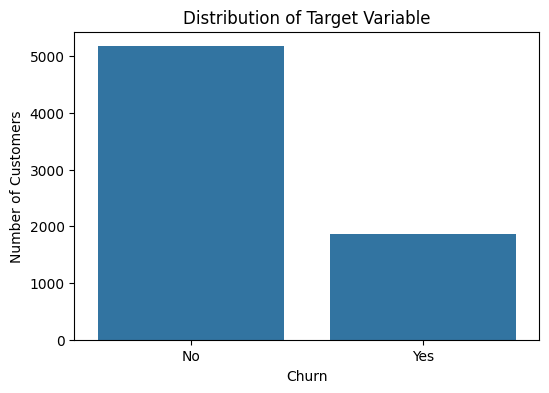

In [31]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="Churn"
)

plt.title("Distribution of Target Variable")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

In [32]:
churn_pct = df["Churn"].value_counts(normalize=True) * 100

print(churn_pct.round(2))

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


In [33]:
identifier_col = "customerID"

target_col = "Churn"

numerical_features = [
    "tenure",
    "Monthly_Charges",
    "Total_Charges"
]

binary_features = [
    "gender",
    "Senior_Citizen",
    "Is_Married",
    "Dependents",
    "Phone_Service",
    "Paperless_Billing"
]

categorical_features = [
    "Dual",
    "Internet_Service",
    "Online_Security",
    "Online_Backup",
    "Device_Protection",
    "Tech_Support",
    "Streaming_TV",
    "Streaming_Movies",
    "Contract",
    "Payment_Method"
]

EDA

In [34]:
df[numerical_features].describe().T

,count,mean,std,min,25%,50%,75%,max
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.00,55.00,72.00
Monthly_Charges,7043.0,64.761692,30.090047,18.25,35.50,70.35,89.85,118.75
Total_Charges,7043.0,2279.734304,2266.794470,0.00,398.55,1394.55,3786.60,8684.80


In [35]:
df[numerical_features].skew()

tenure             0.239540
Monthly_Charges   -0.220524
Total_Charges      0.963235
dtype: float64

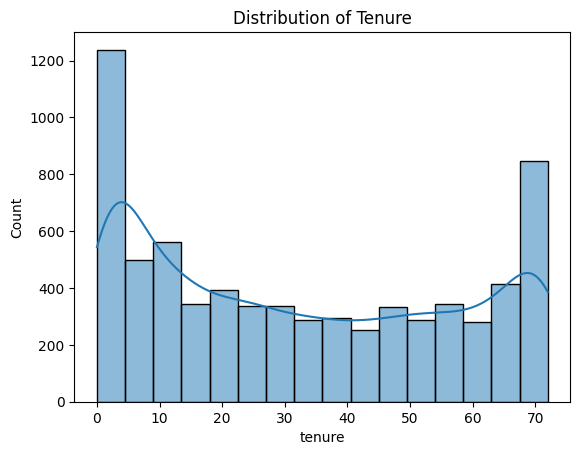

In [36]:
sns.histplot(
    data=df,
    x="tenure",
    kde=True
)

plt.title("Distribution of Tenure")
plt.show()

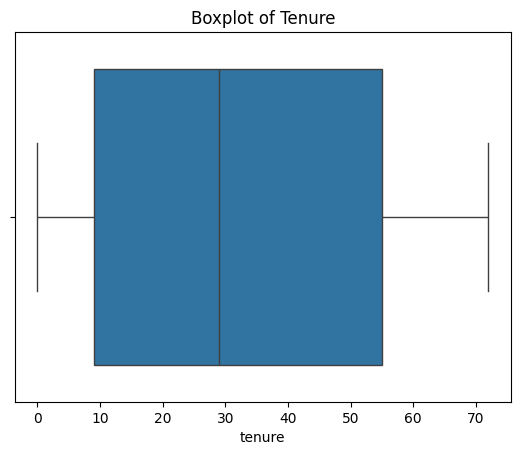

In [37]:
sns.boxplot(
    data=df,
    x="tenure"
)

plt.title("Boxplot of Tenure")
plt.show()

In [38]:
df["tenure"].describe()
df["tenure"].skew()

np.float64(0.2395397495619829)

In [39]:
df["Monthly_Charges"].describe()
df["Monthly_Charges"].skew()

np.float64(-0.22052443394398033)

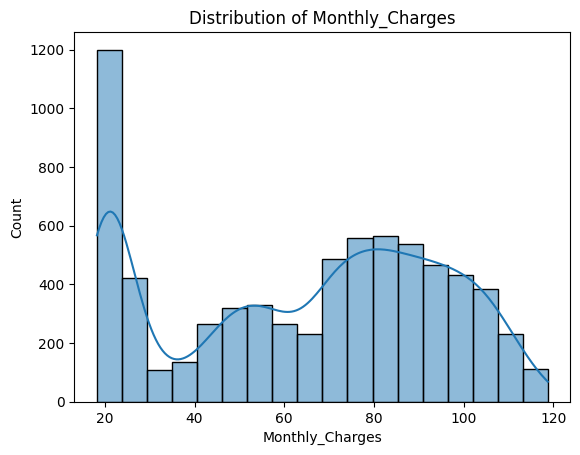

In [40]:
sns.histplot(
    data=df,
    x="Monthly_Charges",
    kde=True
)

plt.title("Distribution of Monthly_Charges")
plt.show()

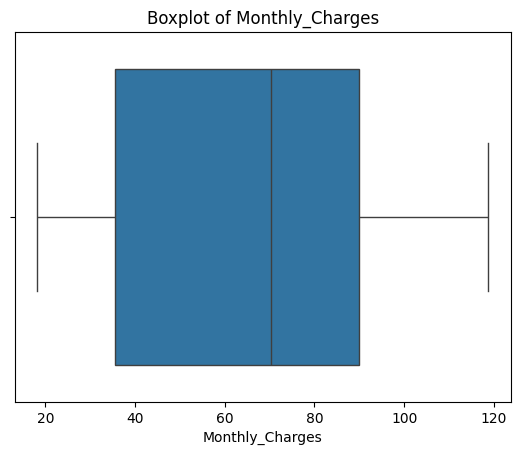

In [41]:
sns.boxplot(
    data=df,
    x="Monthly_Charges"
)

plt.title("Boxplot of Monthly_Charges")
plt.show()

In [42]:
df["Total_Charges"].describe()
df["Total_Charges"].skew()

np.float64(0.963234654832277)

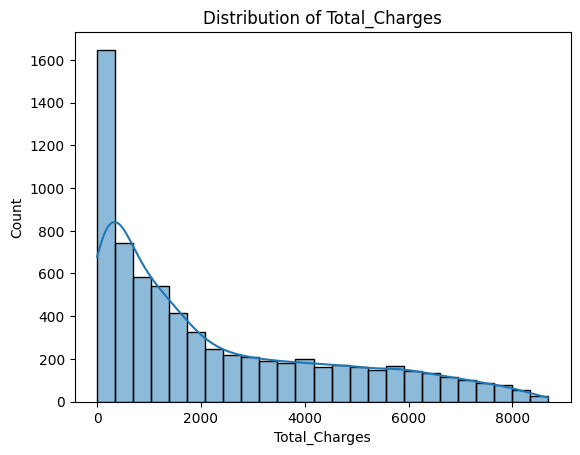

In [43]:
sns.histplot(
    data=df,
    x="Total_Charges",
    kde=True
)

plt.title("Distribution of Total_Charges")
plt.show()

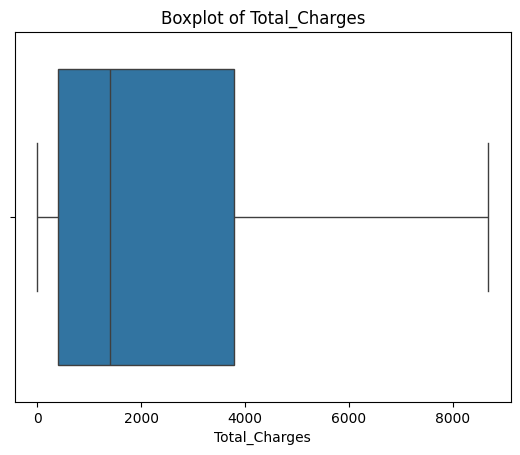

In [44]:
sns.boxplot(
    data=df,
    x="Total_Charges"
)

plt.title("Boxplot of Total_Charges")
plt.show()

In [45]:
categorical_features = [
    "gender",
    "Senior_Citizen",
    "Is_Married",
    "Dependents",
    "Phone_Service",
    "Dual",
    "Internet_Service",
    "Online_Security",
    "Online_Backup",
    "Device_Protection",
    "Tech_Support",
    "Streaming_TV",
    "Streaming_Movies",
    "Contract",
    "Paperless_Billing",
    "Payment_Method"
]

In [46]:
df.columns = df.columns.str.strip()

In [47]:
for number, column in enumerate(df.columns, start=1):
    print(f"{number:02}. {repr(column)}")

01. 'customerID'
02. 'gender'
03. 'Senior_Citizen'
04. 'Is_Married'
05. 'Dependents'
06. 'tenure'
07. 'Phone_Service'
08. 'Dual'
09. 'Internet_Service'
10. 'Online_Security'
11. 'Online_Backup'
12. 'Device_Protection'
13. 'Tech_Support'
14. 'Streaming_TV'
15. 'Streaming_Movies'
16. 'Contract'
17. 'Paperless_Billing'
18. 'Payment_Method'
19. 'Monthly_Charges'
20. 'Total_Charges'
21. 'Churn'


In [48]:
for col in categorical_features:
    print(f"\n{'=' * 50}")
    print(col)
    print(df[col].value_counts())
    print((df[col].value_counts(normalize=True) * 100).round(2))


gender
gender
Male      3555
Female    3488
Name: count, dtype: int64
gender
Male      50.48
Female    49.52
Name: proportion, dtype: float64

Senior_Citizen
Senior_Citizen
0    5901
1    1142
Name: count, dtype: int64
Senior_Citizen
0    83.79
1    16.21
Name: proportion, dtype: float64

Is_Married
Is_Married
No     3641
Yes    3402
Name: count, dtype: int64
Is_Married
No     51.7
Yes    48.3
Name: proportion, dtype: float64

Dependents
Dependents
No     4933
Yes    2110
Name: count, dtype: int64
Dependents
No     70.04
Yes    29.96
Name: proportion, dtype: float64

Phone_Service
Phone_Service
Yes    6361
No      682
Name: count, dtype: int64
Phone_Service
Yes    90.32
No      9.68
Name: proportion, dtype: float64

Dual
Dual
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64
Dual
No                  48.13
Yes                 42.18
No phone service     9.68
Name: proportion, dtype: float64

Internet_Service
Internet_Service
Fiber optic

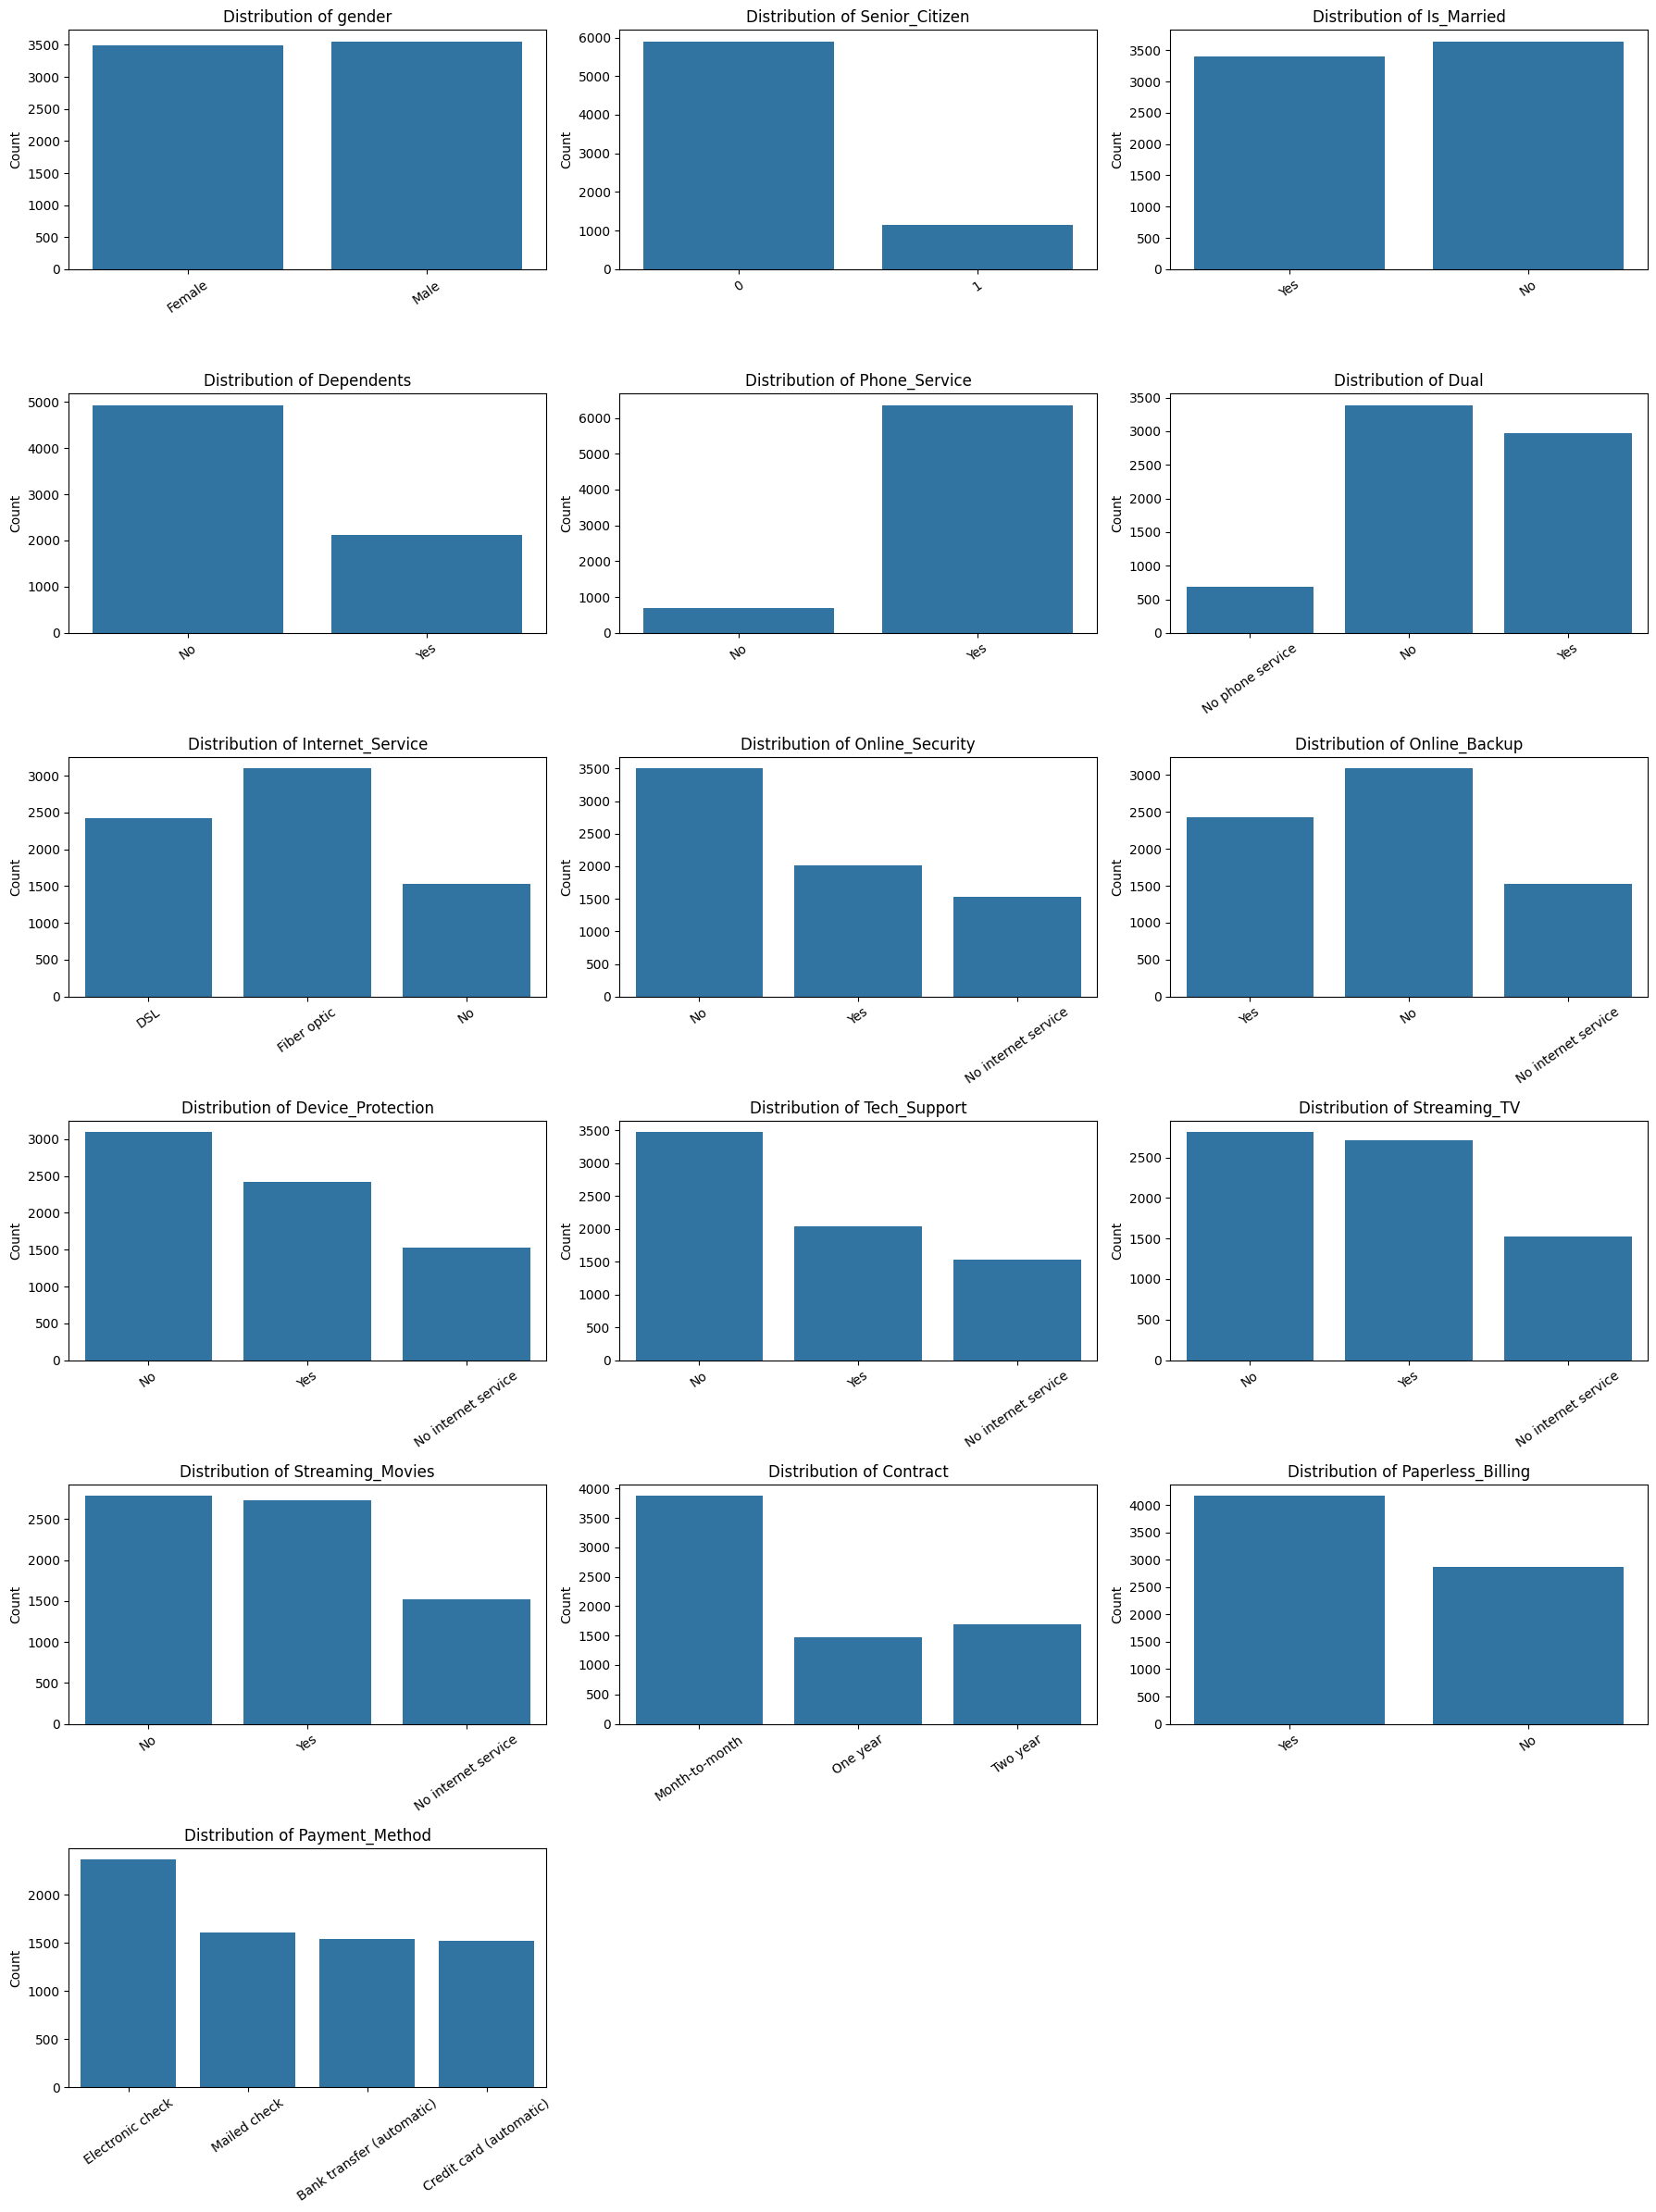

In [49]:
n_cols = 3
n_rows = int(np.ceil(len(categorical_features) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, n_rows * 4)
)

axes = axes.flatten()

for i, col in enumerate(categorical_features):
    sns.countplot(
        data=df,
        x=col,
        ax=axes[i]
    )

    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Count")

    axes[i].tick_params(axis="x", rotation=35)

# Remove unused subplot spaces
for j in range(len(categorical_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [50]:
for col in categorical_features:
    churn_rate = (
        pd.crosstab(
            df[col],
            df["Churn"],
            normalize="index"
        ) * 100
    )

    print(f"\n{'=' * 60}")
    print(col)
    print(churn_rate.round(2))


gender
Churn      No    Yes
gender              
Female  73.08  26.92
Male    73.84  26.16

Senior_Citizen
Churn              No    Yes
Senior_Citizen              
0               76.39  23.61
1               58.32  41.68

Is_Married
Churn          No    Yes
Is_Married              
No          67.04  32.96
Yes         80.34  19.66

Dependents
Churn          No    Yes
Dependents              
No          68.72  31.28
Yes         84.55  15.45

Phone_Service
Churn             No    Yes
Phone_Service              
No             75.07  24.93
Yes            73.29  26.71

Dual
Churn                No    Yes
Dual                          
No                74.96  25.04
No phone service  75.07  24.93
Yes               71.39  28.61

Internet_Service
Churn                No    Yes
Internet_Service              
DSL               81.04  18.96
Fiber optic       58.11  41.89
No                92.60   7.40

Online_Security
Churn                   No    Yes
Online_Security                  
No    

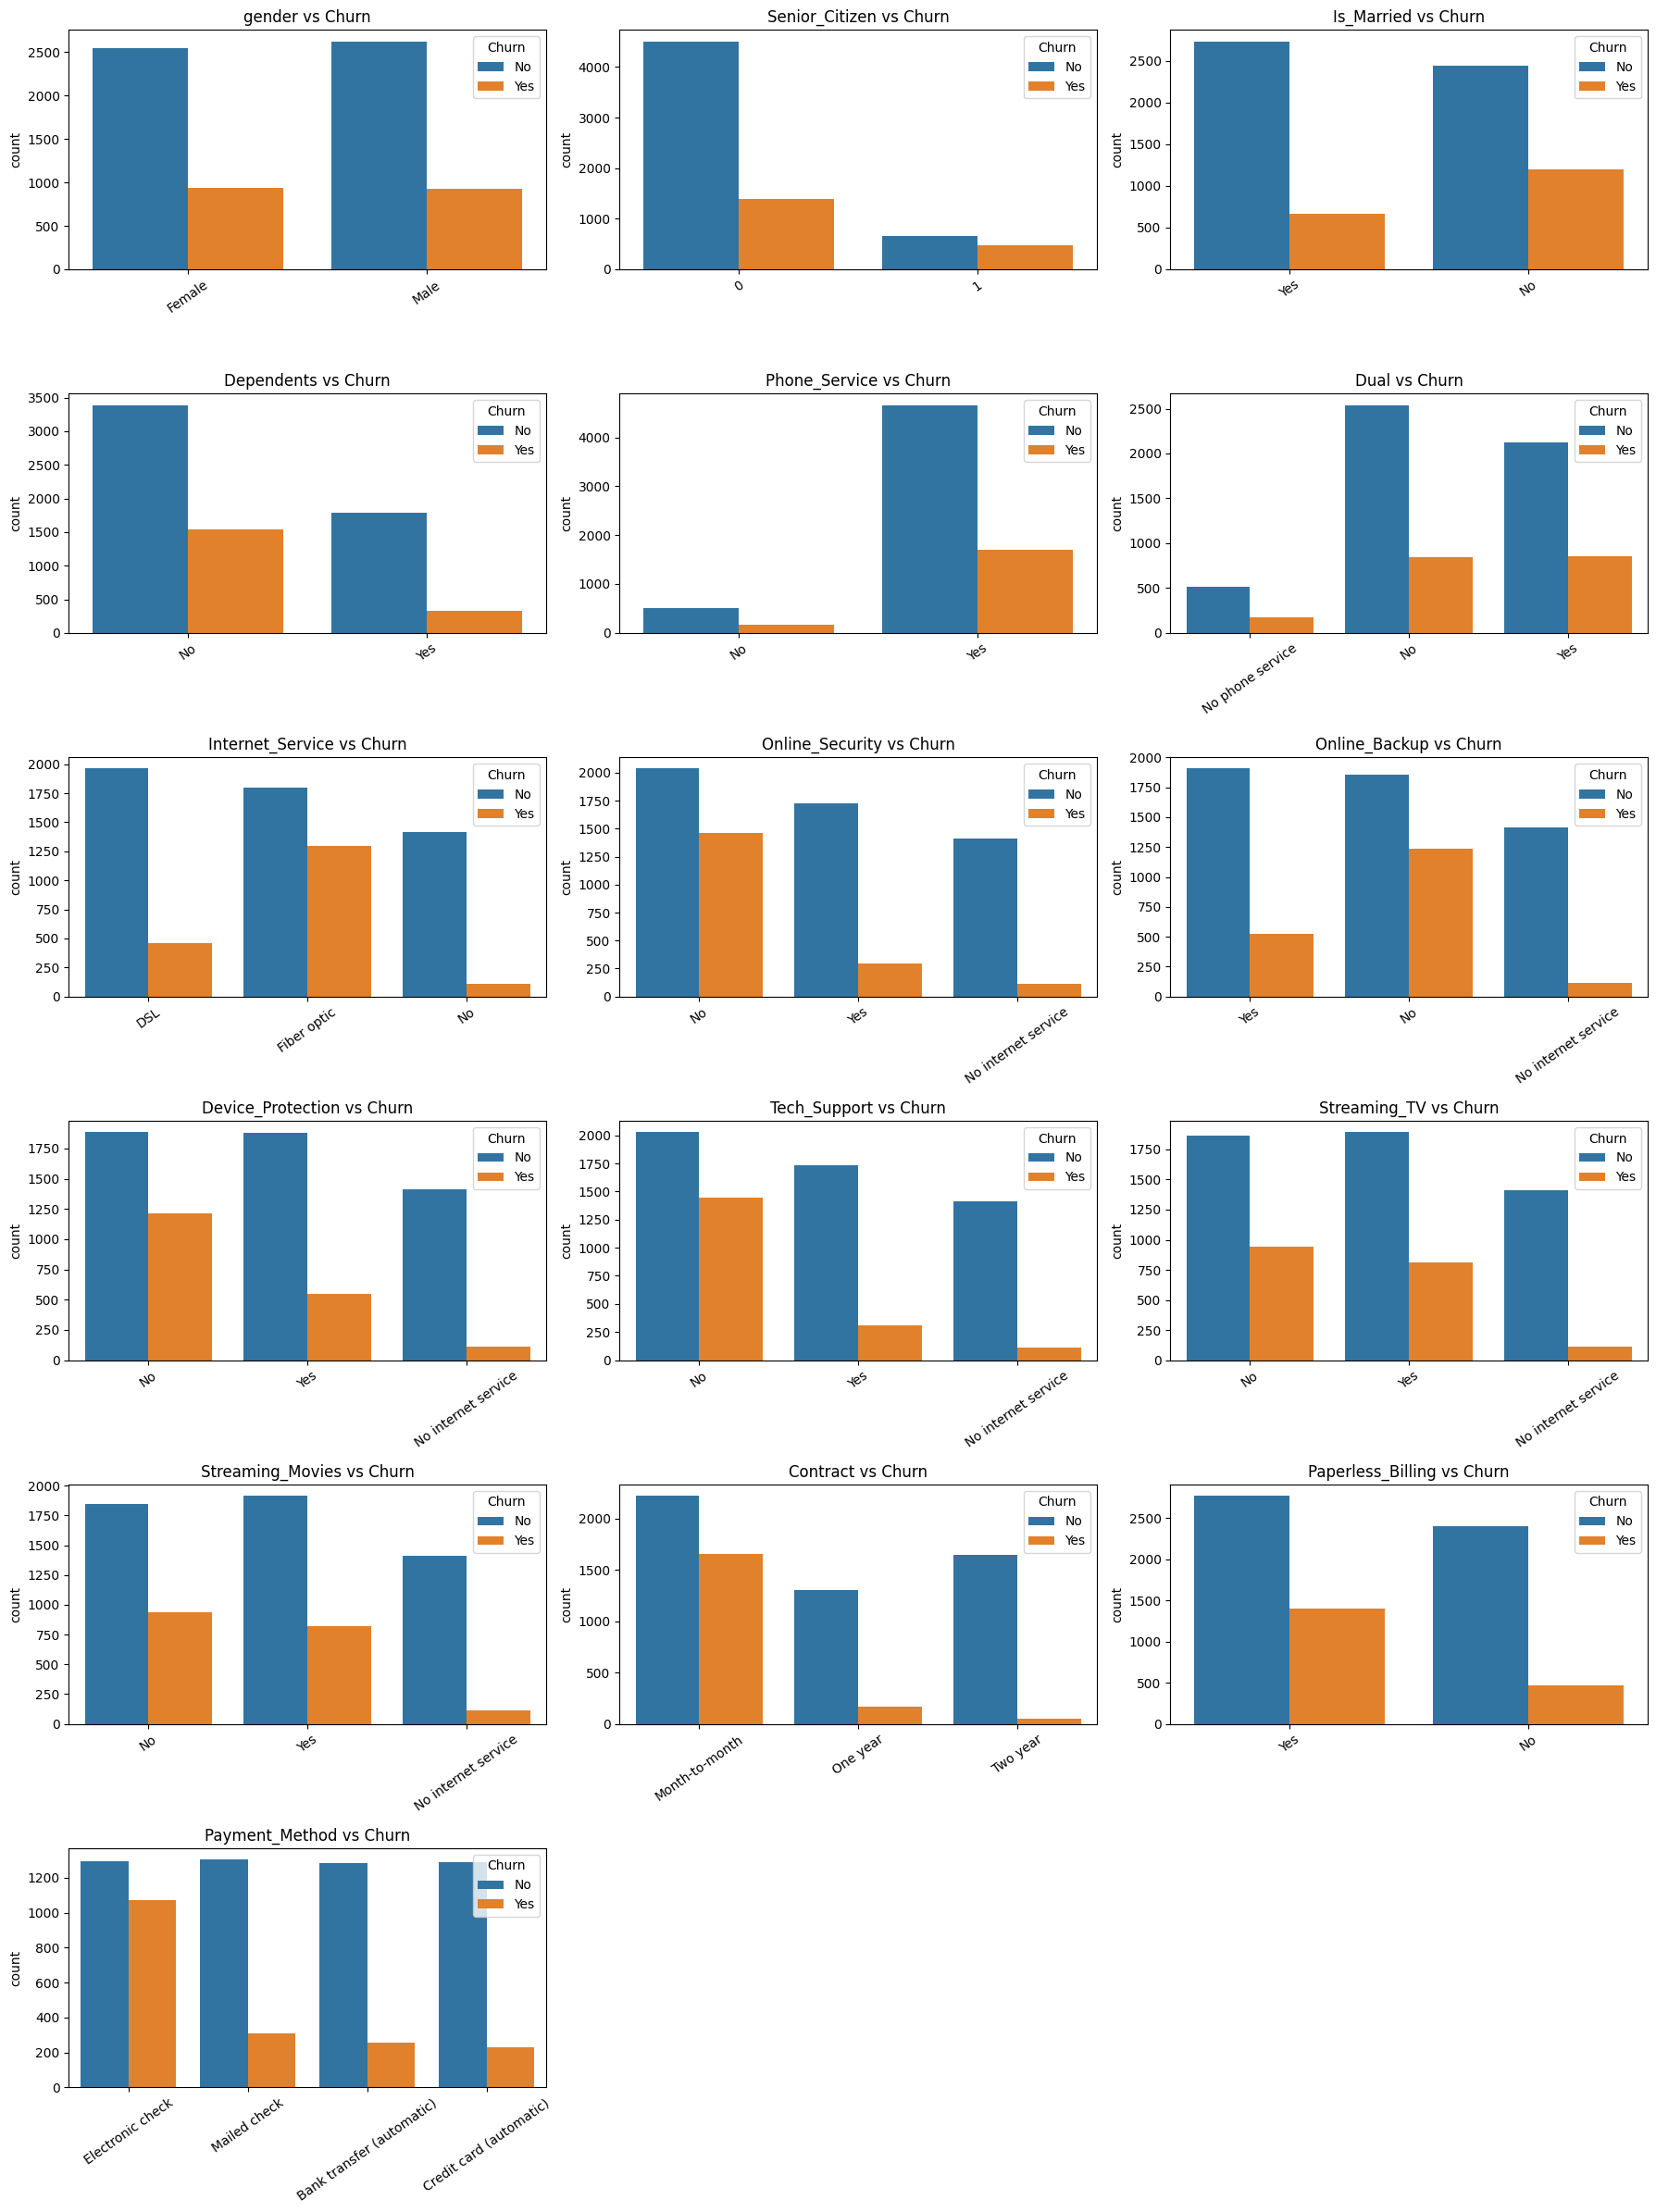

In [51]:
n_cols = 3
n_rows = int(np.ceil(len(categorical_features) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, n_rows * 4)
)

axes = axes.flatten()

for i, col in enumerate(categorical_features):
    sns.countplot(
        data=df,
        x=col,
        hue="Churn",
        ax=axes[i]
    )

    axes[i].set_title(f"{col} vs Churn")
    axes[i].set_xlabel("")
    axes[i].tick_params(axis="x", rotation=35)

for j in range(len(categorical_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [52]:
for col in categorical_features:
    churn_rate = (
        df.groupby(col)["Churn"]
        .apply(lambda x: (x == "Yes").mean() * 100)
        .sort_values(ascending=False)
    )

    print(f"\n{'=' * 60}")
    print(col)
    print(churn_rate.round(2))


gender
gender
Female    26.92
Male      26.16
Name: Churn, dtype: float64

Senior_Citizen
Senior_Citizen
1    41.68
0    23.61
Name: Churn, dtype: float64

Is_Married
Is_Married
No     32.96
Yes    19.66
Name: Churn, dtype: float64

Dependents
Dependents
No     31.28
Yes    15.45
Name: Churn, dtype: float64

Phone_Service
Phone_Service
Yes    26.71
No     24.93
Name: Churn, dtype: float64

Dual
Dual
Yes                 28.61
No                  25.04
No phone service    24.93
Name: Churn, dtype: float64

Internet_Service
Internet_Service
Fiber optic    41.89
DSL            18.96
No              7.40
Name: Churn, dtype: float64

Online_Security
Online_Security
No                     41.77
Yes                    14.61
No internet service     7.40
Name: Churn, dtype: float64

Online_Backup
Online_Backup
No                     39.93
Yes                    21.53
No internet service     7.40
Name: Churn, dtype: float64

Device_Protection
Device_Protection
No                     39.13
Yes   

In [53]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)

    chi2 = chi2_contingency(confusion_matrix)[0]

    n = confusion_matrix.to_numpy().sum()
    phi2 = chi2 / n

    r, k = confusion_matrix.shape

    return np.sqrt(
        phi2 / min(k - 1, r - 1)
    )

In [54]:
categorical_results = []

for col in categorical_features:
    table = pd.crosstab(df[col], df["Churn"])

    chi2, p_value, dof, expected = chi2_contingency(table)

    v = cramers_v(df[col], df["Churn"])

    categorical_results.append({
        "Feature": col,
        "Chi2": chi2,
        "p_value": p_value,
        "Cramers_V": v
    })

categorical_results = pd.DataFrame(
    categorical_results
).sort_values(
    "Cramers_V",
    ascending=False
)

categorical_results

,Feature,Chi2,p_value,Cramers_V
13,Contract,1184.596572,5.863038e-258,0.410116
7,Online_Security,849.998968,2.661150e-185,0.347400
10,Tech_Support,828.197068,1.443084e-180,0.342916
6,Internet_Service,732.309590,9.571788e-160,0.322455
15,Payment_Method,648.142327,3.682355e-140,0.303359
8,Online_Backup,601.812790,2.079759e-131,0.292316
9,Device_Protection,558.419369,5.505219e-122,0.281580
12,Streaming_Movies,375.661479,2.667757e-82,0.230951
11,Streaming_TV,374.203943,5.528994e-82,0.230502
14,Paperless_Billing,258.277649,4.073355e-58,0.191498


In [55]:
numerical_features = [
    "tenure",
    "Monthly_Charges",
    "Total_Charges"
]

df.groupby("Churn")[numerical_features].agg(
    ["mean", "median", "std"]
).round(2)

tenure               Monthly_Charges               Total_Charges  \
        mean median    std            mean median    std          mean   
Churn                                                                    
No     37.57   38.0  24.11           61.27  64.43  31.09       2549.91   
Yes    17.98   10.0  19.53           74.44  79.65  24.67       1531.80   

                         
        median      std  
Churn                    
No     1679.52  2329.95  
Yes     703.55  1890.82

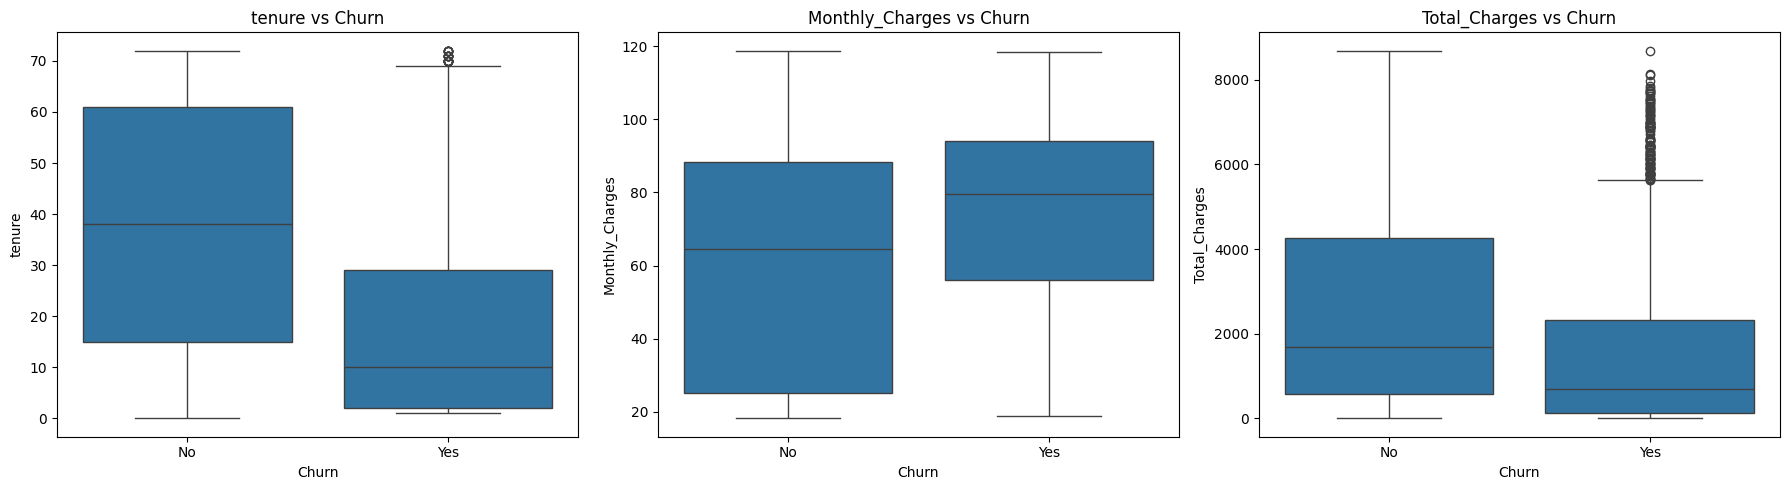

In [56]:
fig, axes = plt.subplots(
    1,
    len(numerical_features),
    figsize=(18, 5)
)

for ax, col in zip(axes, numerical_features):
    sns.boxplot(
        data=df,
        x="Churn",
        y=col,
        ax=ax
    )

    ax.set_title(f"{col} vs Churn")

plt.tight_layout()
plt.show()

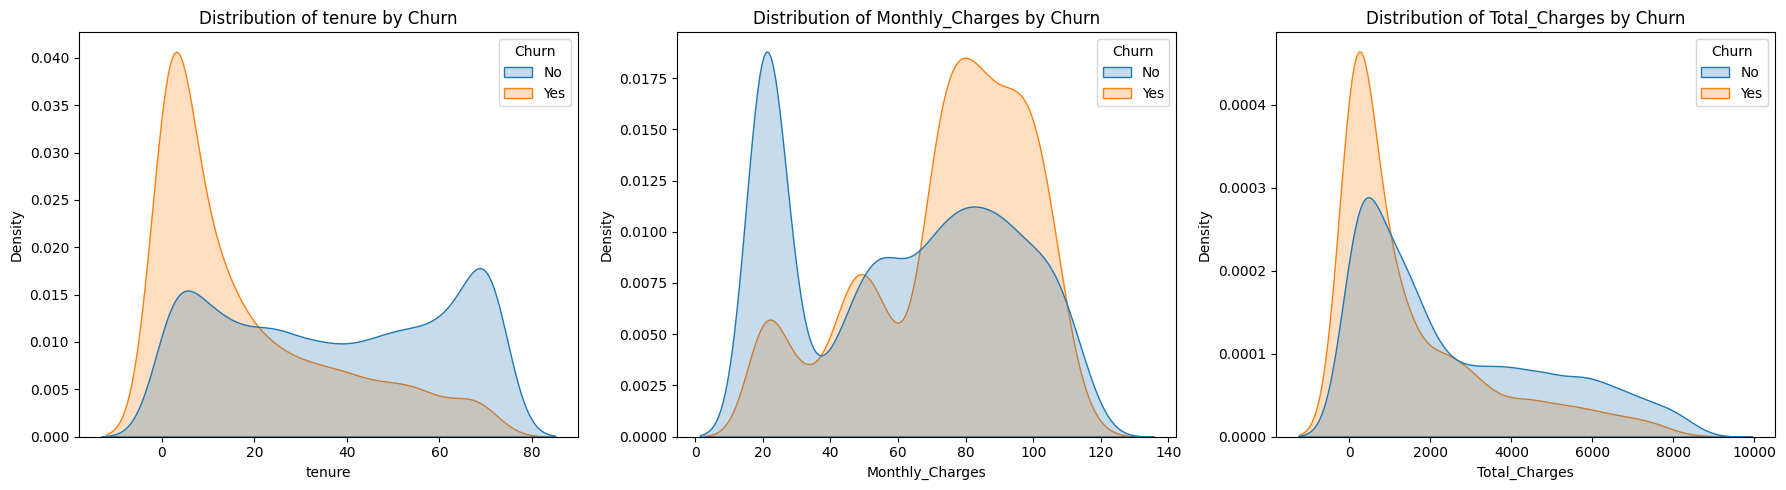

In [57]:
fig, axes = plt.subplots(
    1,
    len(numerical_features),
    figsize=(18, 5)
)

for ax, col in zip(axes, numerical_features):
    sns.kdeplot(
        data=df,
        x=col,
        hue="Churn",
        fill=True,
        common_norm=False,
        ax=ax
    )

    ax.set_title(f"Distribution of {col} by Churn")

plt.tight_layout()
plt.show()

In [58]:
from scipy.stats import mannwhitneyu

numerical_results = []

for col in numerical_features:
    churn_yes = df.loc[df["Churn"] == "Yes", col]
    churn_no = df.loc[df["Churn"] == "No", col]

    statistic, p_value = mannwhitneyu(
        churn_yes,
        churn_no,
        alternative="two-sided"
    )

    numerical_results.append({
        "Feature": col,
        "U_statistic": statistic,
        "p_value": p_value
    })

pd.DataFrame(numerical_results)

,Feature,U_statistic,p_value
0,tenure,2515538.0,2.419636e-208
1,Monthly_Charges,6003125.5,3.311628e-54
2,Total_Charges,3381224.0,5.685034e-83


In [59]:
from scipy.stats import mannwhitneyu

numerical_results = []

for col in numerical_features:
    churn_yes = df.loc[df["Churn"] == "Yes", col]
    churn_no = df.loc[df["Churn"] == "No", col]

    u_stat, p_value = mannwhitneyu(
        churn_yes,
        churn_no,
        alternative="two-sided"
    )

    n_yes = len(churn_yes)
    n_no = len(churn_no)

    rank_biserial = (
        2 * u_stat / (n_yes * n_no)
    ) - 1

    numerical_results.append({
        "Feature": col,
        "U_statistic": u_stat,
        "p_value": p_value,
        "Rank_Biserial": rank_biserial
    })

numerical_results = pd.DataFrame(numerical_results)

numerical_results

,Feature,U_statistic,p_value,Rank_Biserial
0,tenure,2515538.0,2.419636e-208,-0.479734
1,Monthly_Charges,6003125.5,3.311628e-54,0.241571
2,Total_Charges,3381224.0,5.685034e-83,-0.300692


Feature to feature analysis


In [60]:
df[numerical_features].corr(method="spearman")

,tenure,Monthly_Charges,Total_Charges
tenure,1.000000,0.276417,0.889696
Monthly_Charges,0.276417,1.000000,0.638028
Total_Charges,0.889696,0.638028,1.000000


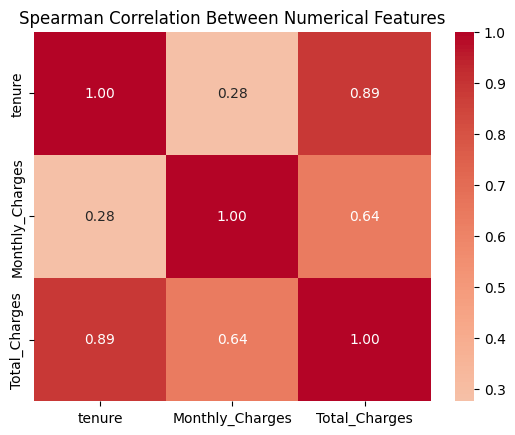

In [61]:
corr = df[numerical_features].corr(method="spearman")

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Spearman Correlation Between Numerical Features")
plt.show()

In [62]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    table = pd.crosstab(x, y)

    chi2 = chi2_contingency(table)[0]
    n = table.to_numpy().sum()

    phi2 = chi2 / n

    r, k = table.shape

    return np.sqrt(phi2 / min(k - 1, r - 1))

In [63]:
cramers_matrix = pd.DataFrame(
    index=categorical_features,
    columns=categorical_features,
    dtype=float
)

for col1 in categorical_features:
    for col2 in categorical_features:
        cramers_matrix.loc[col1, col2] = cramers_v(
            df[col1],
            df[col2]
        )

cramers_matrix

,gender,Senior_Citizen,Is_Married,Dependents,Phone_Service,Dual,Internet_Service,Online_Security,Online_Backup,Device_Protection,Tech_Support,Streaming_TV,Streaming_Movies,Contract,Paperless_Billing,Payment_Method
gender,0.999716,0.001488,0.001524,0.010207,0.006008,0.009452,0.011320,0.017025,0.013798,0.006029,0.009722,0.008844,0.010641,0.008153,0.011465,0.018646
Senior_Citizen,0.001488,0.999477,0.016093,0.210765,0.007925,0.146643,0.265324,0.211070,0.182774,0.183071,0.224050,0.185586,0.188962,0.143868,0.156138,0.195985
Is_Married,0.001524,0.016093,0.999716,0.452366,0.017225,0.143898,0.000907,0.152010,0.153337,0.166568,0.127642,0.137343,0.129574,0.296039,0.014588,0.162762
Dependents,0.010207,0.210765,0.452366,0.999662,0.001238,0.025094,0.180267,0.194579,0.162760,0.157570,0.182377,0.147082,0.141335,0.244212,0.111062,0.150744
Phone_Service,0.006008,0.007925,0.017225,0.001238,0.999188,1.000000,0.452425,0.176272,0.172818,0.172317,0.176977,0.180434,0.177520,0.003976,0.016016,0.010297
Dual,0.009452,0.146643,0.143898,0.025094,1.000000,1.000000,0.396726,0.229608,0.245163,0.246342,0.230162,0.261791,0.262356,0.080408,0.166341,0.166930
Internet_Service,0.011320,0.265324,0.000907,0.180267,0.452425,0.396726,1.000000,0.724466,0.707184,0.707108,0.722904,0.717099,0.716008,0.206921,0.378427,0.313123
Online_Security,0.017025,0.211070,0.152010,0.194579,0.176272,0.229608,0.724466,1.000000,0.718434,0.717291,0.733071,0.707788,0.708208,0.301349,0.341800,0.304959
Online_Backup,0.013798,0.182774,0.153337,0.162760,0.172818,0.245163,0.707184,0.718434,1.000000,0.719125,0.719834,0.714699,0.713682,0.258572,0.321046,0.282517
Device_Protection,0.006029,0.183071,0.166568,0.157570,0.172317,0.246342,0.707108,0.717291,0.719125,1.000000,0.726485,0.733661,0.736047,0.296976,0.321631,0.287021


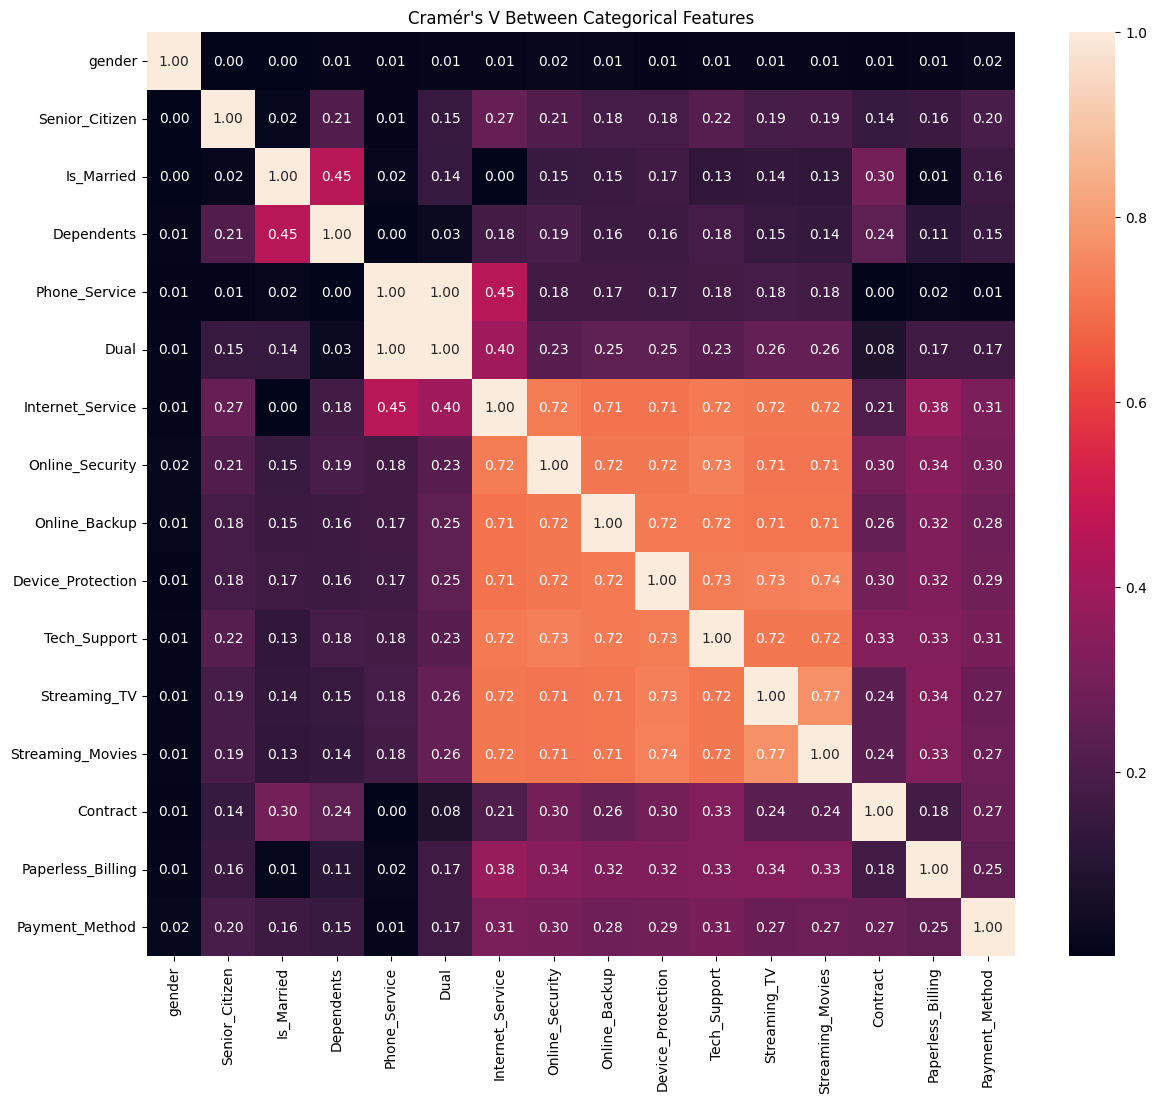

In [64]:
plt.figure(figsize=(14, 12))

sns.heatmap(
    cramers_matrix,
    annot=True,
    fmt=".2f"
)

plt.title("Cramér's V Between Categorical Features")
plt.show()

Leakage and feature validity

In [65]:
X = df.drop(columns=["customerID", "Churn"])
y = df["Churn"]

In [66]:
y = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

In [67]:
y.value_counts()
y.value_counts(normalize=True)

Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64

Split the data

In [68]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["customerID", "Churn"])
y = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

In [69]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

assert X_train.index.intersection(X_test.index).empty

print("\nTrain target distribution:")
print(y_train.value_counts(normalize=True).round(4))
print("\nTest set reserved for the final frozen-model evaluation.")

X_train: (5634, 19)
X_test : (1409, 19)

Train target distribution:
Churn
0    0.7346
1    0.2654
Name: proportion, dtype: float64

Test set reserved for the final frozen-model evaluation.


Preprocessing for modeling

In [70]:
numerical_features = [
    "tenure",
    "Monthly_Charges",
    "Total_Charges"
]

categorical_features = [
    "gender",
    "Senior_Citizen",
    "Is_Married",
    "Dependents",
    "Phone_Service",
    "Dual",
    "Internet_Service",
    "Online_Security",
    "Online_Backup",
    "Device_Protection",
    "Tech_Support",
    "Streaming_TV",
    "Streaming_Movies",
    "Contract",
    "Paperless_Billing",
    "Payment_Method"
]

Categorical preprocessing 

In [71]:
from sklearn.preprocessing import OneHotEncoder
categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore"
        ))
    ]
)


#no neeed for numerical preprocessing cause we have no missing values 

In [72]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numerical_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

Baseline Model

In [73]:
from sklearn.dummy import DummyClassifier

dummy_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DummyClassifier(
            strategy="most_frequent"
        ))
    ]
)

In [74]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

dummy_oof_pred = cross_val_predict(
    dummy_pipeline, X_train, y_train, cv=cv, method="predict"
)

In [75]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

print("OOF Accuracy :", accuracy_score(y_train, dummy_oof_pred))
print("OOF Precision:", precision_score(y_train, dummy_oof_pred, zero_division=0))
print("OOF Recall   :", recall_score(y_train, dummy_oof_pred, zero_division=0))
print("OOF F1       :", f1_score(y_train, dummy_oof_pred, zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_train, dummy_oof_pred))

OOF Accuracy : 0.7346467873624423
OOF Precision: 0.0
OOF Recall   : 0.0
OOF F1       : 0.0

Confusion Matrix:
[[4139    0]
 [1495    0]]


Logistic Regression model

In [76]:
from sklearn.linear_model import LogisticRegression

logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

In [77]:
initial_logistic_oof_proba = cross_val_predict(
    logistic_pipeline, X_train, y_train, cv=cv, method="predict_proba"
)[:, 1]
initial_logistic_oof_pred = (initial_logistic_oof_proba >= 0.50).astype(int)

d:\work\telco-churn-assistant\.venv\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
d:\work\telco-churn-assistant\.venv\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logisti

In [78]:
print("OOF Accuracy :", accuracy_score(y_train, initial_logistic_oof_pred))
print("OOF Precision:", precision_score(y_train, initial_logistic_oof_pred))
print("OOF Recall   :", recall_score(y_train, initial_logistic_oof_pred))
print("OOF F1       :", f1_score(y_train, initial_logistic_oof_pred))
print("OOF ROC-AUC  :", roc_auc_score(y_train, initial_logistic_oof_proba))

OOF Accuracy : 0.8033368832090877
OOF Precision: 0.6551724137931034
OOF Recall   : 0.5464882943143813
OOF F1       : 0.5959153902261123
OOF ROC-AUC  : 0.8454771926393931


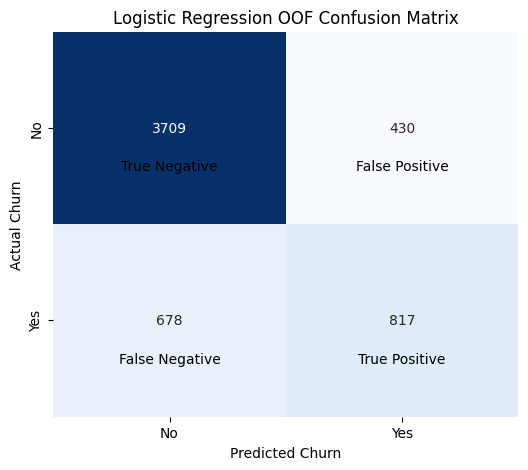

In [79]:
cm = confusion_matrix(y_train, initial_logistic_oof_pred)

labels = [
    ["True Negative", "False Positive"],
    ["False Negative", "True Positive"]
]

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["No", "Yes"],
    yticklabels=["No", "Yes"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j + 0.5,
            i + 0.7,
            labels[i][j],
            ha="center",
            va="center",
            color="black",
            fontsize=10
        )

plt.title("Logistic Regression OOF Confusion Matrix")
plt.xlabel("Predicted Churn")
plt.ylabel("Actual Churn")
plt.show()

Logistic Regression with CrossValidation

In [80]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_results = cross_validate(
    logistic_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

for metric in scoring:
    scores = cv_results[f"test_{metric}"]

    print(
        f"{metric}: "
        f"{scores.mean():.4f} ± {scores.std():.4f}"
    )

d:\work\telco-churn-assistant\.venv\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
d:\work\telco-churn-assistant\.venv\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logisti

accuracy: 0.8033 ± 0.0123
precision: 0.6554 ± 0.0279
recall: 0.5465 ± 0.0416
f1: 0.5953 ± 0.0305
roc_auc: 0.8460 ± 0.0126


d:\work\telco-churn-assistant\.venv\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Scalling Numerical Variables 

In [81]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

numeric_pipeline_scaled = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor_scaled = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline_scaled, numerical_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

logistic_pipeline_scaled = Pipeline(
    steps=[
        ("preprocessor", preprocessor_scaled),
        ("model", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

In [82]:
cv_results_scaled = cross_validate(
    logistic_pipeline_scaled,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

for metric in scoring:
    scores = cv_results_scaled[f"test_{metric}"]

    print(
        f"{metric}: "
        f"{scores.mean():.4f} ± {scores.std():.4f}"
    )

accuracy: 0.8019 ± 0.0118
precision: 0.6521 ± 0.0256
recall: 0.5438 ± 0.0409
f1: 0.5924 ± 0.0298
roc_auc: 0.8461 ± 0.0126


In [83]:
comparison = pd.DataFrame({
    "Metric": list(scoring.keys()),
    "Unscaled_Mean": [
        cv_results[f"test_{metric}"].mean()
        for metric in scoring
    ],
    "Scaled_Mean": [
        cv_results_scaled[f"test_{metric}"].mean()
        for metric in scoring
    ]
})

comparison["Difference"] = (
    comparison["Scaled_Mean"]
    - comparison["Unscaled_Mean"]
)

comparison

,Metric,Unscaled_Mean,Scaled_Mean,Difference
0,accuracy,0.803339,0.801918,-0.001420
1,precision,0.655445,0.652094,-0.003352
2,recall,0.546488,0.543813,-0.002676
3,f1,0.595336,0.592412,-0.002924
4,roc_auc,0.845992,0.846149,0.000157


Testing diffrent model families

In [84]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

models = {
    "Logistic Regression": logistic_pipeline_scaled,

    "Decision Tree": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", DecisionTreeClassifier(
                random_state=42
            ))
        ]
    ),

    "Random Forest": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                n_jobs=-1
            ))
        ]
    ),

    "XGBoost": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", xgb.XGBClassifier(
                random_state=42,
                eval_metric="logloss"
            ))
        ]
    ),

    "CatBoost": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", CatBoostClassifier(
                random_state=42,
                verbose=0
            ))
        ]
    )
}

In [85]:
model_results = []

for model_name, model in models.items():

    cv_result = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    model_results.append({
        "Model": model_name,

        "Accuracy_Mean":
            cv_result["test_accuracy"].mean(),

        "Accuracy_Std":
            cv_result["test_accuracy"].std(),

        "Precision_Mean":
            cv_result["test_precision"].mean(),

        "Recall_Mean":
            cv_result["test_recall"].mean(),

        "F1_Mean":
            cv_result["test_f1"].mean(),

        "ROC_AUC_Mean":
            cv_result["test_roc_auc"].mean(),

        "ROC_AUC_Std":
            cv_result["test_roc_auc"].std()
    })

In [86]:
model_results = []

for model_name, model in models.items():

    cv_result = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    row = {"Model": model_name}

    for metric in scoring:
        row[f"{metric}_mean"] = (
            cv_result[f"test_{metric}"].mean()
        )

        row[f"{metric}_std"] = (
            cv_result[f"test_{metric}"].std()
        )

    model_results.append(row)

results_df = pd.DataFrame(model_results)

results_df.sort_values(
    "roc_auc_mean",
    ascending=False
).round(4)

,Model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
0,Logistic Regression,0.8019,0.0118,0.6521,0.0256,0.5438,0.0409,0.5924,0.0298,0.8461,0.0126
4,CatBoost,0.7966,0.0128,0.6517,0.0332,0.5023,0.0258,0.5672,0.0271,0.8419,0.0088
3,XGBoost,0.7875,0.0116,0.6243,0.0331,0.5050,0.0148,0.5580,0.0180,0.8213,0.0068
2,Random Forest,0.7865,0.0103,0.6271,0.0301,0.4849,0.0194,0.5466,0.0189,0.8202,0.0120
1,Decision Tree,0.7307,0.0060,0.4931,0.0116,0.5003,0.0317,0.4961,0.0151,0.6573,0.0105


Tuning logistic Regression

In [87]:
from sklearn.model_selection import GridSearchCV

param_grid_logistic = {
    "model__C": [
        0.01,
        0.1,
        0.5,
        1,
        2,
        5,
        10
    ],

    "model__class_weight": [
        None,
        "balanced"
    ]
}

In [88]:
logistic_grid = GridSearchCV(
    estimator=logistic_pipeline_scaled,
    param_grid=param_grid_logistic,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

logistic_grid.fit(
    X_train,
    y_train
)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['tenure',
                                                                          'Monthly_Charges',
                                                                          'Total_Charges']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='m...
                                                                          'Online_Security',
                                                                          'Online_Backup',
                                                                          'Device_Protection',
                                                                          'Tech_Support',
                                                                          'Streaming_TV',
                                                                          'Streaming_Movies',
                                                                          'Contract',
                                                                          'Paperless_Billing',
                                                                          'Payment_Method'])])),
                                       ('model',
                                        LogisticRegression(max_iter=1000,
                                                           random_state=42))]),
             n_jobs=-1,
             param_grid={'model__C': [0.01, 0.1, 0.5, 1, 2, 5, 10],
                         'model__class_weight': [None, 'balanced']},
             return_train_score=True, scoring='roc_auc')

In [89]:
print("Best parameters:")
print(logistic_grid.best_params_)

print("\nBest CV ROC-AUC:")
print(logistic_grid.best_score_)

Best parameters:
{'model__C': 5, 'model__class_weight': None}

Best CV ROC-AUC:
0.8463777425217069


In [90]:
best_logistic = logistic_grid.best_estimator_

In [91]:
best_logistic_cv = cross_validate(
    best_logistic,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

for metric in scoring:
    scores = best_logistic_cv[f"test_{metric}"]

    print(
        f"{metric}: "
        f"{scores.mean():.4f} ± {scores.std():.4f}"
    )

accuracy: 0.8035 ± 0.0126
precision: 0.6548 ± 0.0274
recall: 0.5492 ± 0.0404
f1: 0.5968 ± 0.0306
roc_auc: 0.8464 ± 0.0128


Evaluating catboost with the raw categorical variables without preprocessing

In [92]:
X_train_cb = X_train.copy()

for col in categorical_features:
    X_train_cb[col] = X_train_cb[col].astype(str)

In [93]:
from catboost import CatBoostClassifier

catboost_native = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=0
)

In [94]:
catboost_native_cv = cross_validate(
    catboost_native,
    X_train_cb,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    params={
        "cat_features": categorical_features
    }
)

In [95]:
for metric in scoring:
    scores = catboost_native_cv[f"test_{metric}"]

    print(
        f"{metric}: "
        f"{scores.mean():.4f} ± {scores.std():.4f}"
    )

accuracy: 0.8016 ± 0.0124
precision: 0.6627 ± 0.0350
recall: 0.5171 ± 0.0252
f1: 0.5803 ± 0.0235
roc_auc: 0.8437 ± 0.0095


Tuning Catboost

In [96]:
from sklearn.model_selection import RandomizedSearchCV

catboost_param_dist = {
    "depth": [4, 5, 6, 7, 8],
    "learning_rate": [0.02, 0.03, 0.05, 0.07, 0.1],
    "iterations": [300, 400, 500, 600, 800],
    "l2_leaf_reg": [2, 3, 5, 7, 10]
}

catboost_model = CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=0,
    thread_count=1
)

random_cb = RandomizedSearchCV(
    estimator=catboost_model,
    param_distributions=catboost_param_dist,
    n_iter=25,
    scoring="roc_auc",
    cv=cv,
    random_state=42,
    n_jobs=4
)

random_cb.fit(
    X_train_cb,
    y_train,
    cat_features=categorical_features
)

print("Best params:", random_cb.best_params_)
print("Best ROC-AUC:", random_cb.best_score_)

Best params: {'learning_rate': 0.02, 'l2_leaf_reg': 7, 'iterations': 600, 'depth': 4}
Best ROC-AUC: 0.8506048308280052


In [97]:
best_catboost = random_cb.best_estimator_

In [98]:
best_catboost_cv = cross_validate(
    best_catboost,
    X_train_cb,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    params={
        "cat_features": categorical_features
    }
)

for metric in scoring:
    scores = best_catboost_cv[f"test_{metric}"]

    print(
        f"{metric}: "
        f"{scores.mean():.4f} ± {scores.std():.4f}"
    )

accuracy: 0.8049 ± 0.0109
precision: 0.6699 ± 0.0298
recall: 0.5237 ± 0.0206
f1: 0.5876 ± 0.0214
roc_auc: 0.8506 ± 0.0117


Ensmble Model
- logistic Regression better at Recall and F1
- Catboost better at ROC-AUC and Precision

Start With soft voting ensmble


In [99]:
# Generate out-of-fold probabilities for Logistic Regression and CatBoost

from sklearn.base import clone
from catboost import CatBoostClassifier

oof_logistic = np.zeros(len(X_train))
oof_catboost = np.zeros(len(X_train))

for train_idx, val_idx in cv.split(X_train, y_train):

    X_tr = X_train.iloc[train_idx]
    X_val = X_train.iloc[val_idx]

    y_tr = y_train.iloc[train_idx]
    y_val = y_train.iloc[val_idx]

    # Logistic Regression
    logistic_fold = clone(best_logistic)
    logistic_fold.fit(X_tr, y_tr)

    oof_logistic[val_idx] = logistic_fold.predict_proba(X_val)[:, 1]

    # CatBoost
    X_tr_cb = X_tr.copy()
    X_val_cb = X_val.copy()

    for col in categorical_features:
        X_tr_cb[col] = X_tr_cb[col].astype(str)
        X_val_cb[col] = X_val_cb[col].astype(str)

    catboost_fold = CatBoostClassifier(
        **random_cb.best_params_,
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=42,
        verbose=0
    )

    catboost_fold.fit(
        X_tr_cb,
        y_tr,
        cat_features=categorical_features
    )

    oof_catboost[val_idx] = catboost_fold.predict_proba(X_val_cb)[:, 1]

In [100]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

def evaluate_ensemble(y_true, probabilities, threshold=0.5):
    predictions = (probabilities >= threshold).astype(int)

    return {
        "accuracy": accuracy_score(y_true, predictions),
        "precision": precision_score(y_true, predictions),
        "recall": recall_score(y_true, predictions),
        "f1": f1_score(y_true, predictions),
        "roc_auc": roc_auc_score(y_true, probabilities)
    }

In [101]:
weights = np.arange(0.0, 1.01, 0.1)

results = []

for logistic_weight in weights:

    catboost_weight = 1 - logistic_weight

    ensemble_proba = (
        logistic_weight * oof_logistic
        +
        catboost_weight * oof_catboost
    )

    metrics = evaluate_ensemble(
        y_train,
        ensemble_proba
    )

    results.append({
        "logistic_weight": logistic_weight,
        "catboost_weight": catboost_weight,
        **metrics
    })

ensemble_results = pd.DataFrame(results)

ensemble_results.round(4)

,logistic_weight,catboost_weight,accuracy,precision,recall,f1,roc_auc
0,0.0,1.0,0.8049,0.6692,0.5237,0.5876,0.8498
1,0.1,0.9,0.8069,0.6726,0.5304,0.5931,0.8501
2,0.2,0.8,0.8071,0.6717,0.5338,0.5949,0.8502
3,0.3,0.7,0.8071,0.6692,0.5398,0.5976,0.8502
4,0.4,0.6,0.8069,0.6678,0.5418,0.5982,0.8500
5,0.5,0.5,0.8065,0.6664,0.5425,0.5981,0.8497
6,0.6,0.4,0.8055,0.6639,0.5405,0.5959,0.8493
7,0.7,0.3,0.8060,0.6634,0.5458,0.5989,0.8487
8,0.8,0.2,0.8042,0.6586,0.5445,0.5961,0.8479
9,0.9,0.1,0.8039,0.6565,0.5472,0.5969,0.8470


In [102]:
best_weight = ensemble_results.loc[
    ensemble_results["roc_auc"].idxmax()
]

best_weight

logistic_weight    0.200000
catboost_weight    0.800000
accuracy           0.807064
precision          0.671717
recall             0.533779
f1                 0.594857
roc_auc            0.850211
Name: 2, dtype: float64

Optimizing threshold for 0.4 logistic and 0.6 catboost

In [103]:
ensemble_proba = (
    0.4 * oof_logistic
    +
    0.6 * oof_catboost
)

In [104]:
thresholds = np.arange(0.20, 0.61, 0.01)

threshold_results = []

for threshold in thresholds:

    y_pred_threshold = (
        ensemble_proba >= threshold
    ).astype(int)

    threshold_results.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_train, y_pred_threshold),
        "precision": precision_score(y_train, y_pred_threshold),
        "recall": recall_score(y_train, y_pred_threshold),
        "f1": f1_score(y_train, y_pred_threshold)
    })

threshold_results_df = pd.DataFrame(threshold_results)

threshold_results_df.round(4)

,threshold,accuracy,precision,recall,f1
0,0.20,0.7112,0.4759,0.8709,0.6155
1,0.21,0.7181,0.4826,0.8649,0.6195
2,0.22,0.7261,0.4908,0.8555,0.6238
3,0.23,0.7343,0.4996,0.8495,0.6292
4,0.24,0.7382,0.5040,0.8388,0.6297
5,0.25,0.7414,0.5079,0.8194,0.6271
6,0.26,0.7485,0.5166,0.8100,0.6309
7,0.27,0.7543,0.5243,0.8013,0.6339
8,0.28,0.7586,0.5302,0.7926,0.6354
9,0.29,0.7661,0.5410,0.7819,0.6395


In [105]:
best_f1_threshold = threshold_results_df.loc[
    threshold_results_df["f1"].idxmax()
]

best_f1_threshold

threshold    0.370000
accuracy     0.791267
precision    0.590164
recall       0.698328
f1           0.639706
Name: 17, dtype: float64

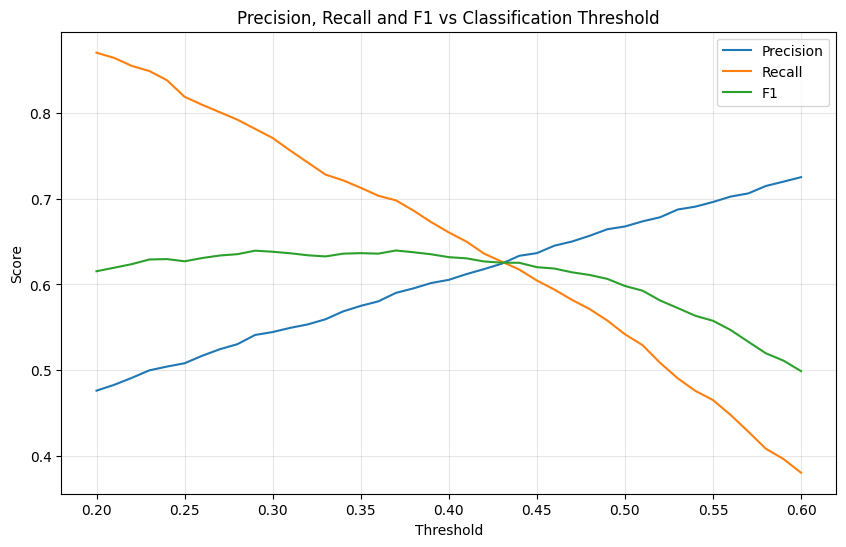

In [106]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_results_df["threshold"],
    threshold_results_df["precision"],
    label="Precision"
)

plt.plot(
    threshold_results_df["threshold"],
    threshold_results_df["recall"],
    label="Recall"
)

plt.plot(
    threshold_results_df["threshold"],
    threshold_results_df["f1"],
    label="F1"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall and F1 vs Classification Threshold")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

Exploratory raw-feature ensemble using training OOF predictions

In [107]:
exploratory_logistic_weight = 0.40
exploratory_catboost_weight = 0.60
exploratory_threshold = 0.37

assert np.isclose(
    exploratory_logistic_weight + exploratory_catboost_weight,
    1.0
)

In [108]:
exploratory_ensemble_oof_proba = (
    exploratory_logistic_weight * oof_logistic
    + exploratory_catboost_weight * oof_catboost
)

In [109]:
exploratory_ensemble_oof_pred = (
    exploratory_ensemble_oof_proba >= exploratory_threshold
).astype(int)

In [110]:
exploratory_ensemble_metrics = {
    "Accuracy": accuracy_score(y_train, exploratory_ensemble_oof_pred),
    "Precision": precision_score(y_train, exploratory_ensemble_oof_pred),
    "Recall": recall_score(y_train, exploratory_ensemble_oof_pred),
    "F1": f1_score(y_train, exploratory_ensemble_oof_pred),
    "ROC_AUC": roc_auc_score(y_train, exploratory_ensemble_oof_proba)
}

In [111]:
pd.Series(exploratory_ensemble_metrics).round(4)

Accuracy     0.7913
Precision    0.5902
Recall       0.6983
F1           0.6397
ROC_AUC      0.8500
dtype: float64

In [112]:
exploratory_cm = confusion_matrix(
    y_train,
    exploratory_ensemble_oof_pred
)

exploratory_cm

array([[3414,  725],
       [ 451, 1044]])

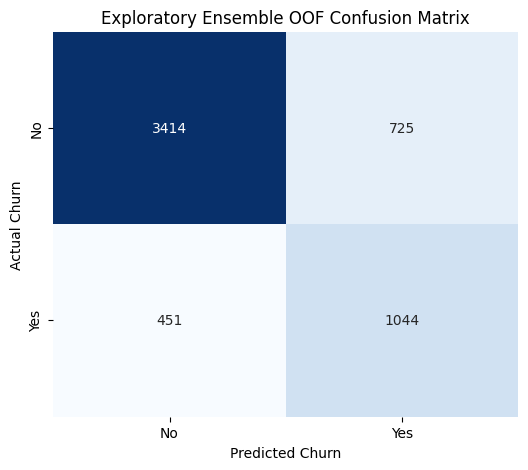

In [113]:
plt.figure(figsize=(6, 5))
sns.heatmap(
    exploratory_cm, annot=True, fmt="d", cmap="Blues", cbar=False,
    xticklabels=["No", "Yes"], yticklabels=["No", "Yes"]
)
plt.title("Exploratory Ensemble OOF Confusion Matrix")
plt.xlabel("Predicted Churn")
plt.ylabel("Actual Churn")
plt.show()

In [114]:
from sklearn.metrics import roc_curve

exploratory_fpr, exploratory_tpr, _ = roc_curve(
    y_train, exploratory_ensemble_oof_proba
)

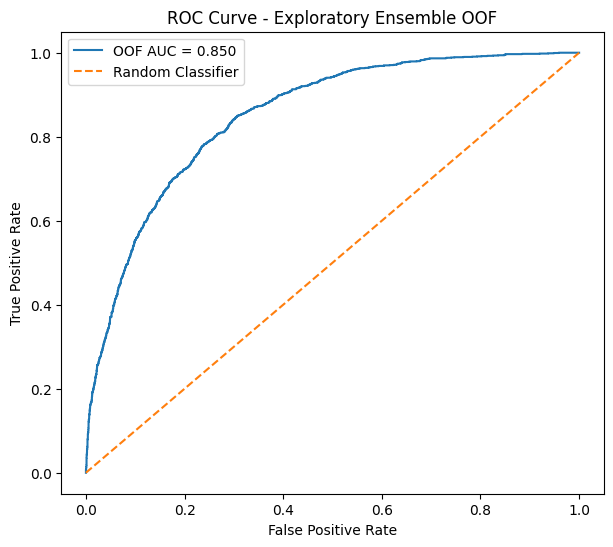

In [115]:
plt.figure(figsize=(7, 6))
plt.plot(
    exploratory_fpr,
    exploratory_tpr,
    label=f"OOF AUC = {exploratory_ensemble_metrics['ROC_AUC']:.3f}"
)
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Exploratory Ensemble OOF")
plt.legend()
plt.show()

In [116]:
assert len(exploratory_ensemble_oof_proba) == len(y_train)
assert np.isfinite(exploratory_ensemble_oof_proba).all()
assert ((exploratory_ensemble_oof_proba >= 0) & (exploratory_ensemble_oof_proba <= 1)).all()

print("Exploratory ensemble validated using training OOF predictions only.")

Exploratory ensemble validated using training OOF predictions only.


In [117]:
pd.DataFrame([{
    "Experiment": "Raw-feature ensemble",
    "Logistic_Weight": exploratory_logistic_weight,
    "CatBoost_Weight": exploratory_catboost_weight,
    "Threshold": exploratory_threshold,
    **exploratory_ensemble_metrics
}]).round(4)

,Experiment,Logistic_Weight,CatBoost_Weight,Threshold,Accuracy,Precision,Recall,F1,ROC_AUC
0,Raw-feature ensemble,0.4,0.6,0.37,0.7913,0.5902,0.6983,0.6397,0.85


Feature Engineering
- create new features
- compare the models before and after this features

In [118]:
def add_engineered_features(X):
    X = X.copy()

    # 1. Total number of optional internet services
    service_cols = [
        "Online_Security",
        "Online_Backup",
        "Device_Protection",
        "Tech_Support",
        "Streaming_TV",
        "Streaming_Movies"
    ]

    X["Num_Services"] = sum(
        (X[col] == "Yes").astype(int)
        for col in service_cols
    )

    # 2. Number of support/protection-related services
    support_cols = [
        "Online_Security",
        "Online_Backup",
        "Device_Protection",
        "Tech_Support"
    ]

    X["Num_Support_Services"] = sum(
        (X[col] == "Yes").astype(int)
        for col in support_cols
    )

    # 3. Number of streaming services
    X["Num_Streaming_Services"] = (
        (X["Streaming_TV"] == "Yes").astype(int)
        +
        (X["Streaming_Movies"] == "Yes").astype(int)
    )

    # 4. New-customer flag
    X["Is_New_Customer"] = (
        X["tenure"] <= 6
    ).astype(int)

    # 5. Automatic payment flag
    X["Auto_Payment"] = X["Payment_Method"].isin([
        "Bank transfer (automatic)",
        "Credit card (automatic)"
    ]).astype(int)

    # 6. No security and no tech support interaction
    X["No_Security_And_No_Support"] = (
        (X["Online_Security"] == "No")
        &
        (X["Tech_Support"] == "No")
    ).astype(int)

    return X

In [119]:
X_fe = add_engineered_features(X)

In [120]:
print("Original shape:", X.shape)
print("Engineered shape:", X_fe.shape)

X_fe[
    [
        "Num_Services",
        "Num_Support_Services",
        "Num_Streaming_Services",
        "Is_New_Customer",
        "Auto_Payment",
        "No_Security_And_No_Support"
    ]
].head()

Original shape: (7043, 19)
Engineered shape: (7043, 25)


,Num_Services,Num_Support_Services,Num_Streaming_Services,Is_New_Customer,Auto_Payment,No_Security_And_No_Support
0,1,1,0,1,0,1
1,2,2,0,0,0,0
2,2,2,0,1,0,0
3,3,3,0,0,1,0
4,0,0,0,1,0,1


In [121]:
numerical_features_fe = [
    "tenure",
    "Monthly_Charges",
    "Total_Charges",
    "Num_Services",
    "Num_Support_Services",
    "Num_Streaming_Services",
    "Is_New_Customer",
    "Auto_Payment",
    "No_Security_And_No_Support"
]

In [122]:
categorical_features_fe = categorical_features.copy()

In [123]:
X_train_fe = add_engineered_features(X_train)
X_test_fe = add_engineered_features(X_test)

y_train_fe = y_train.copy()
y_test_fe = y_test.copy()

In [124]:
print(X_train_fe.shape)
print(X_test_fe.shape)

print(
    y_train_fe.index.equals(y_train.index),
    y_test_fe.index.equals(y_test.index)
)

(5634, 25)
(1409, 25)
True True


Creating the new models with the new Featured Engineered features

In [125]:
numeric_pipeline_scaled_fe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_pipeline_fe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor_scaled_fe = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline_scaled_fe, numerical_features_fe),
        ("cat", categorical_pipeline_fe, categorical_features_fe)
    ]
)

logistic_pipeline_scaled_fe = Pipeline(
    steps=[
        ("preprocessor", preprocessor_scaled_fe),
        ("model", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

In [126]:
cv_results_logistic_fe = cross_validate(
    logistic_pipeline_scaled_fe,
    X_train_fe,
    y_train_fe,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

for metric in scoring:
    scores = cv_results_logistic_fe[f"test_{metric}"]

    print(
        f"{metric}: "
        f"{scores.mean():.4f} ± {scores.std():.4f}"
    )

accuracy: 0.8058 ± 0.0129
precision: 0.6678 ± 0.0272
recall: 0.5331 ± 0.0454
f1: 0.5922 ± 0.0348
roc_auc: 0.8480 ± 0.0119


In [127]:
logistic_fe_comparison = pd.DataFrame({
    "Metric": list(scoring.keys()),

    "Original_Logistic": [
        best_logistic_cv[f"test_{metric}"].mean()
        for metric in scoring
    ],

    "Feature_Engineered_Logistic": [
        cv_results_logistic_fe[f"test_{metric}"].mean()
        for metric in scoring
    ]
})

logistic_fe_comparison["Difference"] = (
    logistic_fe_comparison["Feature_Engineered_Logistic"]
    -
    logistic_fe_comparison["Original_Logistic"]
)

logistic_fe_comparison

,Metric,Original_Logistic,Feature_Engineered_Logistic,Difference
0,accuracy,0.803516,0.805823,0.002307
1,precision,0.654800,0.667774,0.012974
2,recall,0.549164,0.533110,-0.016054
3,f1,0.596782,0.592213,-0.004568
4,roc_auc,0.846378,0.848049,0.001671


In [128]:
#tuning
param_grid_logistic_fe = {
    "model__C": [
        0.01,
        0.1,
        0.5,
        1,
        2,
        5,
        10
    ],
    "model__class_weight": [
        None,
        "balanced"
    ]
}

logistic_grid_fe = GridSearchCV(
    estimator=logistic_pipeline_scaled_fe,
    param_grid=param_grid_logistic_fe,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1
)

logistic_grid_fe.fit(
    X_train_fe,
    y_train_fe
)

print("Best params:", logistic_grid_fe.best_params_)
print("Best ROC-AUC:", logistic_grid_fe.best_score_)

Best params: {'model__C': 5, 'model__class_weight': None}
Best ROC-AUC: 0.8481264834886575


In [129]:
best_logistic_fe = logistic_grid_fe.best_estimator_

best_logistic_fe_cv = cross_validate(
    best_logistic_fe,
    X_train_fe,
    y_train_fe,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

for metric in scoring:
    scores = best_logistic_fe_cv[f"test_{metric}"]
    print(f"{metric}: {scores.mean():.4f} ± {scores.std():.4f}")

accuracy: 0.8067 ± 0.0126
precision: 0.6698 ± 0.0250
recall: 0.5344 ± 0.0463
f1: 0.5939 ± 0.0351
roc_auc: 0.8481 ± 0.0119


In [130]:
X_train_cb_fe = X_train_fe.copy()

for col in categorical_features_fe:
    X_train_cb_fe[col] = X_train_cb_fe[col].astype(str)

In [131]:
catboost_native_fe = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=0
)

catboost_native_fe_cv = cross_validate(
    catboost_native_fe,
    X_train_cb_fe,
    y_train_fe,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    params={
        "cat_features": categorical_features_fe
    }
)

for metric in scoring:
    scores = catboost_native_fe_cv[f"test_{metric}"]
    print(f"{metric}: {scores.mean():.4f} ± {scores.std():.4f}")

accuracy: 0.7998 ± 0.0098
precision: 0.6606 ± 0.0329
recall: 0.5097 ± 0.0275
f1: 0.5745 ± 0.0188
roc_auc: 0.8439 ± 0.0095


In [132]:
from sklearn.model_selection import RandomizedSearchCV

catboost_param_dist_fe = {
    "depth": [4, 5, 6, 7, 8],
    "learning_rate": [0.02, 0.03, 0.05, 0.07, 0.1],
    "iterations": [300, 400, 500, 600, 800],
    "l2_leaf_reg": [2, 3, 5, 7, 10]
}

catboost_model_fe = CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=0,
    thread_count=1
)

random_cb_fe = RandomizedSearchCV(
    estimator=catboost_model_fe,
    param_distributions=catboost_param_dist_fe,
    n_iter=25,
    scoring="roc_auc",
    cv=cv,
    random_state=42,
    n_jobs=4
)

random_cb_fe.fit(
    X_train_cb_fe,
    y_train_fe,
    cat_features=categorical_features_fe
)

print("Best params:", random_cb_fe.best_params_)
print("Best ROC-AUC:", random_cb_fe.best_score_)

Best params: {'learning_rate': 0.02, 'l2_leaf_reg': 7, 'iterations': 600, 'depth': 4}
Best ROC-AUC: 0.85086008958668


In [133]:
best_catboost_fe = random_cb_fe.best_estimator_

best_catboost_fe_cv = cross_validate(
    best_catboost_fe,
    X_train_cb_fe,
    y_train_fe,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    params={
        "cat_features": categorical_features_fe
    }
)

for metric in scoring:
    scores = best_catboost_fe_cv[f"test_{metric}"]

    print(
        f"{metric}: "
        f"{scores.mean():.4f} ± {scores.std():.4f}"
    )

accuracy: 0.8053 ± 0.0133
precision: 0.6696 ± 0.0323
recall: 0.5264 ± 0.0319
f1: 0.5891 ± 0.0294
roc_auc: 0.8509 ± 0.0114


In [134]:
catboost_fe_comparison = pd.DataFrame({
    "Metric": list(scoring.keys()),

    "Original_CatBoost": [
        best_catboost_cv[f"test_{metric}"].mean()
        for metric in scoring
    ],

    "Feature_Engineered_CatBoost": [
        best_catboost_fe_cv[f"test_{metric}"].mean()
        for metric in scoring
    ]
})

catboost_fe_comparison["Difference"] = (
    catboost_fe_comparison["Feature_Engineered_CatBoost"]
    -
    catboost_fe_comparison["Original_CatBoost"]
)

catboost_fe_comparison

,Metric,Original_CatBoost,Feature_Engineered_CatBoost,Difference
0,accuracy,0.804936,0.805290,0.000354
1,precision,0.669901,0.669566,-0.000335
2,recall,0.523746,0.526421,0.002676
3,f1,0.587648,0.589089,0.001442
4,roc_auc,0.850605,0.850860,0.000255


Creating ensemble model with hybrid approach logistic regression on raw features and CatBoost on Feature Engineered features
- logistic regression base model act worse with the feature engineered features
- catboost act better while having the Feature engineered features than the basemodel

In [135]:
from sklearn.base import clone
import numpy as np
import pandas as pd

# OOF probability containers
oof_logistic_hybrid = np.zeros(len(X_train))
oof_catboost_hybrid = np.zeros(len(X_train))

for train_idx, val_idx in cv.split(X_train, y_train):

    # =========================================================
    # 1. Logistic Regression using RAW features
    # =========================================================
    X_tr_raw = X_train.iloc[train_idx]
    X_val_raw = X_train.iloc[val_idx]

    y_tr = y_train.iloc[train_idx]

    logistic_fold = clone(best_logistic)

    logistic_fold.fit(
        X_tr_raw,
        y_tr
    )

    oof_logistic_hybrid[val_idx] = logistic_fold.predict_proba(
        X_val_raw
    )[:, 1]


    # =========================================================
    # 2. CatBoost using FEATURE-ENGINEERED features
    # =========================================================
    X_tr_fe = X_train_fe.iloc[train_idx].copy()
    X_val_fe = X_train_fe.iloc[val_idx].copy()

    # CatBoost categorical features should be strings
    for col in categorical_features_fe:
        X_tr_fe[col] = X_tr_fe[col].astype(str)
        X_val_fe[col] = X_val_fe[col].astype(str)

    catboost_fold = CatBoostClassifier(
        **random_cb_fe.best_params_,
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=42,
        verbose=0,
        thread_count=1
    )

    catboost_fold.fit(
        X_tr_fe,
        y_tr,
        cat_features=categorical_features_fe
    )

    oof_catboost_hybrid[val_idx] = catboost_fold.predict_proba(
        X_val_fe
    )[:, 1]

In [136]:
print(oof_logistic_hybrid.shape)
print(oof_catboost_hybrid.shape)

print(oof_logistic_hybrid[:5])
print(oof_catboost_hybrid[:5])

(5634,)
(5634,)
[0.3813115  0.29304602 0.03857144 0.09011236 0.37874257]
[0.41587981 0.26329304 0.02278698 0.08919433 0.61678071]


In [137]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

hybrid_weight_results = []

for logistic_weight in np.arange(0, 1.01, 0.1):

    catboost_weight = 1 - logistic_weight

    hybrid_proba = (
        logistic_weight * oof_logistic_hybrid
        +
        catboost_weight * oof_catboost_hybrid
    )

    hybrid_pred = (hybrid_proba >= 0.5).astype(int)

    hybrid_weight_results.append({
        "Logistic_Weight": round(logistic_weight, 1),
        "CatBoost_Weight": round(catboost_weight, 1),

        "Accuracy": accuracy_score(y_train, hybrid_pred),
        "Precision": precision_score(y_train, hybrid_pred),
        "Recall": recall_score(y_train, hybrid_pred),
        "F1": f1_score(y_train, hybrid_pred),

        "ROC_AUC": roc_auc_score(
            y_train,
            hybrid_proba
        )
    })

hybrid_weight_df = pd.DataFrame(hybrid_weight_results)

hybrid_weight_df

,Logistic_Weight,CatBoost_Weight,Accuracy,Precision,Recall,F1,ROC_AUC
0,0.0,1.0,0.805289,0.669218,0.526421,0.589292,0.850000
1,0.1,0.9,0.805467,0.668639,0.529097,0.590739,0.850268
2,0.2,0.8,0.807419,0.671980,0.535786,0.596204,0.850444
3,0.3,0.7,0.807419,0.670549,0.539130,0.597701,0.850470
4,0.4,0.6,0.806532,0.667217,0.540468,0.597191,0.850346
5,0.5,0.5,0.806177,0.665571,0.541806,0.597345,0.849987
6,0.6,0.4,0.805467,0.662857,0.543144,0.597059,0.849472
7,0.7,0.3,0.805289,0.661789,0.544482,0.597431,0.848804
8,0.8,0.2,0.804047,0.658556,0.543144,0.595308,0.848017
9,0.9,0.1,0.804047,0.657028,0.547157,0.597080,0.847049


In [138]:
hybrid_weight_df.sort_values(
    by="F1",
    ascending=False
)

,Logistic_Weight,CatBoost_Weight,Accuracy,Precision,Recall,F1,ROC_AUC
3,0.3,0.7,0.807419,0.670549,0.539130,0.597701,0.850470
7,0.7,0.3,0.805289,0.661789,0.544482,0.597431,0.848804
5,0.5,0.5,0.806177,0.665571,0.541806,0.597345,0.849987
10,1.0,0.0,0.803514,0.654705,0.549164,0.597308,0.845883
4,0.4,0.6,0.806532,0.667217,0.540468,0.597191,0.850346
9,0.9,0.1,0.804047,0.657028,0.547157,0.597080,0.847049
6,0.6,0.4,0.805467,0.662857,0.543144,0.597059,0.849472
2,0.2,0.8,0.807419,0.671980,0.535786,0.596204,0.850444
8,0.8,0.2,0.804047,0.658556,0.543144,0.595308,0.848017
1,0.1,0.9,0.805467,0.668639,0.529097,0.590739,0.850268


In [139]:
hybrid_weight_df.sort_values(
    by="ROC_AUC",
    ascending=False
)

,Logistic_Weight,CatBoost_Weight,Accuracy,Precision,Recall,F1,ROC_AUC
3,0.3,0.7,0.807419,0.670549,0.539130,0.597701,0.850470
2,0.2,0.8,0.807419,0.671980,0.535786,0.596204,0.850444
4,0.4,0.6,0.806532,0.667217,0.540468,0.597191,0.850346
1,0.1,0.9,0.805467,0.668639,0.529097,0.590739,0.850268
0,0.0,1.0,0.805289,0.669218,0.526421,0.589292,0.850000
5,0.5,0.5,0.806177,0.665571,0.541806,0.597345,0.849987
6,0.6,0.4,0.805467,0.662857,0.543144,0.597059,0.849472
7,0.7,0.3,0.805289,0.661789,0.544482,0.597431,0.848804
8,0.8,0.2,0.804047,0.658556,0.543144,0.595308,0.848017
9,0.9,0.1,0.804047,0.657028,0.547157,0.597080,0.847049


In [140]:
hybrid_logistic_weight = 0.3
hybrid_catboost_weight = 0.7

hybrid_oof_proba = (
    hybrid_logistic_weight * oof_logistic_hybrid
    +
    hybrid_catboost_weight * oof_catboost_hybrid
)

In [141]:
threshold_results_hybrid = []

for threshold in np.arange(0.20, 0.61, 0.01):

    hybrid_pred = (
        hybrid_oof_proba >= threshold
    ).astype(int)

    threshold_results_hybrid.append({
        "Threshold": round(threshold, 2),
        "Accuracy": accuracy_score(y_train, hybrid_pred),
        "Precision": precision_score(y_train, hybrid_pred),
        "Recall": recall_score(y_train, hybrid_pred),
        "F1": f1_score(y_train, hybrid_pred)
    })

threshold_results_hybrid = pd.DataFrame(
    threshold_results_hybrid
)

threshold_results_hybrid.sort_values(
    "F1",
    ascending=False
).head(10)

,Threshold,Accuracy,Precision,Recall,F1
11,0.31,0.772808,0.552516,0.756522,0.638622
10,0.30,0.768726,0.545498,0.769900,0.638558
18,0.38,0.794817,0.599765,0.681605,0.638071
12,0.32,0.776003,0.558690,0.741806,0.637356
9,0.29,0.764466,0.538853,0.779264,0.637134
15,0.35,0.785055,0.577174,0.710368,0.636882
13,0.33,0.778488,0.563627,0.731773,0.636787
19,0.39,0.796947,0.606428,0.668896,0.636132
14,0.34,0.780795,0.568493,0.721739,0.636015
7,0.27,0.755414,0.525579,0.804013,0.635643


In [142]:
from sklearn.metrics import average_precision_score

def summarize_oof_candidate(model_name, probabilities, y_true):
    threshold_rows = []

    for threshold in np.arange(0.05, 0.81, 0.01):
        predictions = (probabilities >= threshold).astype(int)
        threshold_rows.append({
            "Threshold": round(float(threshold), 2),
            "Accuracy": accuracy_score(y_true, predictions),
            "Precision": precision_score(y_true, predictions, zero_division=0),
            "Recall": recall_score(y_true, predictions, zero_division=0),
            "F1": f1_score(y_true, predictions, zero_division=0)
        })

    best_row = pd.DataFrame(threshold_rows).loc[
        lambda frame: frame["F1"].idxmax()
    ].to_dict()

    return {
        "Model": model_name,
        "ROC_AUC": roc_auc_score(y_true, probabilities),
        "PR_AUC": average_precision_score(y_true, probabilities),
        "Best_Threshold": best_row["Threshold"],
        "Accuracy": best_row["Accuracy"],
        "Precision": best_row["Precision"],
        "Recall": best_row["Recall"],
        "F1": best_row["F1"]
    }


final_comparison_table = pd.DataFrame([
    summarize_oof_candidate(
        "Logistic Regression - Raw", oof_logistic_hybrid, y_train
    ),
    summarize_oof_candidate(
        "CatBoost - Raw", oof_catboost, y_train
    ),
    summarize_oof_candidate(
        "CatBoost - Feature Engineered", oof_catboost_hybrid, y_train
    ),
    summarize_oof_candidate(
        "Hybrid Ensemble", hybrid_oof_proba, y_train
    )
]).sort_values(
    ["F1", "ROC_AUC"], ascending=False
).reset_index(drop=True)

final_comparison_table.round(4)

,Model,ROC_AUC,PR_AUC,Best_Threshold,Accuracy,Precision,Recall,F1
0,CatBoost - Feature Engineered,0.8500,0.6688,0.33,0.7804,0.5661,0.7391,0.6411
1,CatBoost - Raw,0.8498,0.6677,0.38,0.7962,0.6027,0.6809,0.6394
2,Hybrid Ensemble,0.8505,0.6705,0.31,0.7728,0.5525,0.7565,0.6386
3,Logistic Regression - Raw,0.8459,0.6581,0.33,0.7756,0.5582,0.7411,0.6368


Final model training and one-time test evaluation

In [143]:
FINAL_LOGISTIC_WEIGHT = 0.30
FINAL_CATBOOST_WEIGHT = 0.70
FINAL_THRESHOLD = float(
    final_comparison_table.loc[
        final_comparison_table["Model"] == "Hybrid Ensemble",
        "Best_Threshold"
    ].iloc[0]
)

In [144]:
assert FINAL_LOGISTIC_WEIGHT + FINAL_CATBOOST_WEIGHT == 1.0

In [145]:
from sklearn.base import clone

final_logistic = clone(best_logistic)

final_logistic.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['tenure', 'Monthly_Charges',
                                                   'Total_Charges']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'Senior_Citizen',
                                                   'Is_Married', 'Dependents',
                                                   'Phone_Service', 'Dual',
                                                   'Internet_Service',
                                                   'Online_Security',
                                                   'Online_Backup',
                                                   'Device_Protection',
                                                   'Tech_Support',
                                                   'Streaming_TV',
                                                   'Streaming_Movies',
                                                   'Contract',
                                                   'Paperless_Billing',
                                                   'Payment_Method'])])),
                ('model',
                 LogisticRegression(C=5, max_iter=1000, random_state=42))])

In [146]:
X_train_cb_fe_final = X_train_fe.copy()
X_test_cb_fe_final = X_test_fe.copy()

for col in categorical_features_fe:
    X_train_cb_fe_final[col] = X_train_cb_fe_final[col].astype(str)
    X_test_cb_fe_final[col] = X_test_cb_fe_final[col].astype(str)

In [147]:
final_catboost_fe = CatBoostClassifier(
    **random_cb_fe.best_params_,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=0
)

final_catboost_fe.fit(
    X_train_cb_fe_final,
    y_train,
    cat_features=categorical_features_fe
)

CatBoostClassifier(depth=4, eval_metric='AUC', iterations=600, l2_leaf_reg=7, learning_rate=0.02, loss_function='Logloss', random_seed=42, verbose=0)

Testing 

In [148]:
test_proba_logistic = final_logistic.predict_proba(
    X_test
)[:, 1]

In [149]:
test_proba_catboost = final_catboost_fe.predict_proba(
    X_test_cb_fe_final
)[:, 1]

In [150]:
final_test_proba = (
    FINAL_LOGISTIC_WEIGHT * test_proba_logistic
    +
    FINAL_CATBOOST_WEIGHT * test_proba_catboost
)

In [151]:
final_test_pred = (
    final_test_proba >= FINAL_THRESHOLD
).astype(int)

In [152]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

final_metrics = {
    "Accuracy": accuracy_score(y_test, final_test_pred),
    "Precision": precision_score(y_test, final_test_pred),
    "Recall": recall_score(y_test, final_test_pred),
    "F1": f1_score(y_test, final_test_pred),
    "ROC_AUC": roc_auc_score(y_test, final_test_proba)
}

for metric, value in final_metrics.items():
    print(f"{metric}: {value:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, final_test_pred))

Accuracy: 0.7644
Precision: 0.5399
Recall: 0.7594
F1: 0.6311
ROC_AUC: 0.8465

Confusion Matrix:
[[793 242]
 [ 90 284]]


Saving the models

In [153]:
from pathlib import Path

MODEL_DIR = PROJECT_ROOT / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

In [154]:
import joblib

joblib.dump(
    final_logistic,
    MODEL_DIR / "logistic_raw.joblib"
)

['D:\\work\\telco-churn-assistant\\models\\logistic_raw.joblib']

In [155]:
final_catboost_fe.save_model(
    MODEL_DIR / "catboost_feature_engineered.cbm"
)

In [156]:
import json

ensemble_config = {
    "logistic_weight": FINAL_LOGISTIC_WEIGHT,
    "catboost_weight": FINAL_CATBOOST_WEIGHT,
    "threshold": FINAL_THRESHOLD,
    "positive_class": 1,
    "negative_class": 0
}

with open(
    MODEL_DIR / "ensemble_config.json",
    "w"
) as f:
    json.dump(
        ensemble_config,
        f,
        indent=4
    )

In [157]:
feature_config = {
    "raw_features": X_train.columns.tolist(),
    "feature_engineered_features": X_train_fe.columns.tolist(),
    "categorical_features": categorical_features_fe,
    "numerical_features": numerical_features_fe
}

with open(
    MODEL_DIR / "feature_config.json",
    "w"
) as f:
    json.dump(
        feature_config,
        f,
        indent=4
    )

In [158]:
for file in MODEL_DIR.iterdir():
    print(file.name)

catboost_feature_engineered.cbm
ensemble_config.json
feature_config.json
logistic_raw.joblib


In [159]:
reloaded_logistic = joblib.load(MODEL_DIR / "logistic_raw.joblib")

reloaded_catboost = CatBoostClassifier()
reloaded_catboost.load_model(
    MODEL_DIR / "catboost_feature_engineered.cbm"
)

reloaded_logistic_proba = reloaded_logistic.predict_proba(X_test)[:, 1]
reloaded_catboost_proba = reloaded_catboost.predict_proba(
    X_test_cb_fe_final
)[:, 1]
reloaded_ensemble_proba = (
    FINAL_LOGISTIC_WEIGHT * reloaded_logistic_proba
    + FINAL_CATBOOST_WEIGHT * reloaded_catboost_proba
)

assert np.allclose(reloaded_logistic_proba, test_proba_logistic)
assert np.allclose(reloaded_catboost_proba, test_proba_catboost)
assert np.allclose(reloaded_ensemble_proba, final_test_proba)

with open(MODEL_DIR / "ensemble_config.json", "r") as f:
    reloaded_config = json.load(f)

assert np.isclose(reloaded_config["logistic_weight"], FINAL_LOGISTIC_WEIGHT)
assert np.isclose(reloaded_config["catboost_weight"], FINAL_CATBOOST_WEIGHT)
assert np.isclose(reloaded_config["threshold"], FINAL_THRESHOLD)

print("Saved-artifact parity check passed.")

Saved-artifact parity check passed.
